## TensorRT 를 터미널에서 실행할 것. 경로에 조심. cd /home/soda/Project/python/notebook/seunghoproject/
## trtexec --onnx=custom-train-yolo4_best.onnx --saveEngine=custom-train-yolo4_best.trt --explicitBatch
## /usr/src/tensorrt/bin/trtexec --onnx=custom-train-yolo4_best.onnx --saveEngine=custom-train-yolo4_best.trt --explicitBatch

# TRT 파일 리드 테스트

In [ ]:
import numpy as np
import time
import os
import sys

# TensorRT 관련 import
try:
    import tensorrt as trt
    import pycuda.driver as cuda
    import pycuda.autoinit
    TRT_AVAILABLE = True
    print("✅ TensorRT 라이브러리 사용 가능")
except ImportError as e:
    TRT_AVAILABLE = False
    print(f"❌ TensorRT 라이브러리 없음: {e}")

# 모델 경로 설정
model_path = "/home/soda/Project/python/notebook/seunghoproject/custom-train-yolo4_best.trt"
classes_path = "/home/soda/Project/python/notebook/seunghoproject/classes.names"

class TensorRTInfer:
    """TensorRT 추론 클래스"""

    def __init__(self, engine_path):
        self.engine_path = engine_path
        self.engine = None
        self.context = None
        self.inputs = []
        self.outputs = []
        self.bindings = []
        self.stream = None

    def load_engine(self):
        """TensorRT 엔진 로딩"""
        print(f"TensorRT 엔진 로딩 중: {self.engine_path}")

        # TensorRT Logger
        TRT_LOGGER = trt.Logger(trt.Logger.WARNING)

        # 엔진 파일 읽기
        with open(self.engine_path, 'rb') as f:
            engine_data = f.read()

        # Runtime 생성 및 엔진 deserialize
        runtime = trt.Runtime(TRT_LOGGER)
        self.engine = runtime.deserialize_cuda_engine(engine_data)

        if self.engine is None:
            print("❌ 엔진 로딩 실패")
            return False

        print("✅ 엔진 로딩 성공")

        # Execution Context 생성
        self.context = self.engine.create_execution_context()

        # 입출력 바인딩 설정
        self._setup_bindings()

        # CUDA 스트림 생성
        self.stream = cuda.Stream()

        return True

    def _setup_bindings(self):
        """입출력 바인딩 설정"""
        self.inputs = []
        self.outputs = []
        self.bindings = []

        for binding in self.engine:
            binding_idx = self.engine.get_binding_index(binding)
            size = trt.volume(self.engine.get_binding_shape(binding)) * self.engine.max_batch_size
            dtype = trt.nptype(self.engine.get_binding_dtype(binding))

            # GPU 메모리 할당
            device_mem = cuda.mem_alloc(size * dtype().itemsize)
            self.bindings.append(int(device_mem))

            if self.engine.binding_is_input(binding):
                # 입력 바인딩
                host_mem = cuda.pagelocked_empty(size, dtype)
                self.inputs.append({'host': host_mem, 'device': device_mem})
                print(f"📥 입력 바인딩: {binding}, 형태: {self.engine.get_binding_shape(binding)}, 타입: {dtype}")
            else:
                # 출력 바인딩
                host_mem = cuda.pagelocked_empty(size, dtype)
                self.outputs.append({'host': host_mem, 'device': device_mem})
                print(f"📤 출력 바인딩: {binding}, 형태: {self.engine.get_binding_shape(binding)}, 타입: {dtype}")

    def infer(self, input_data):
        """추론 실행"""
        # 입력 데이터를 GPU로 복사
        np.copyto(self.inputs[0]['host'], input_data.ravel())
        cuda.memcpy_htod_async(self.inputs[0]['device'], self.inputs[0]['host'], self.stream)

        # 추론 실행
        self.context.execute_async_v2(bindings=self.bindings, stream_handle=self.stream.handle)

        # 출력 데이터를 CPU로 복사
        outputs = []
        for output in self.outputs:
            cuda.memcpy_dtoh_async(output['host'], output['device'], self.stream)
            outputs.append(output['host'].copy())

        # 스트림 동기화
        self.stream.synchronize()

        return outputs

def test_tensorrt_model():
    """TensorRT 모델 테스트"""

    print("=" * 60)
    print("TensorRT 모델 직접 로딩 테스트 시작")
    print("=" * 60)

    # 1. 사전 확인
    if not TRT_AVAILABLE:
        print("TensorRT를 사용할 수 없어 다른 방법을 시도합니다...")
        return test_alternative_methods()

    # 2. 파일 존재 확인
    print(f"1. 모델 파일 확인: {model_path}")
    if not os.path.exists(model_path):
        print("   ❌ 모델 파일이 존재하지 않음")
        return False

    file_size = os.path.getsize(model_path) / (1024 * 1024)
    print(f"   ✅ 파일 존재 (크기: {file_size:.2f} MB)")

    # 3. 클래스 파일 확인
    print(f"\n2. 클래스 파일 확인: {classes_path}")
    if os.path.exists(classes_path):
        with open(classes_path, 'r') as f:
            classes = [line.strip() for line in f.readlines()]
        print(f"   ✅ 클래스 파일 존재 ({len(classes)}개 클래스: {classes})")

    # 4. TensorRT 엔진 로딩 시도
    print(f"\n3. TensorRT 엔진 로딩 시도")
    try:
        infer_engine = TensorRTInfer(model_path)

        start_time = time.time()
        success = infer_engine.load_engine()
        load_time = time.time() - start_time

        if not success:
            return False

        print(f"   ⏱️  로딩 시간: {load_time:.3f}초")

    except Exception as e:
        print(f"   ❌ 엔진 로딩 실패: {str(e)}")
        return False

    # 5. 더미 데이터로 추론 테스트
    print(f"\n4. 추론 테스트")
    try:
        # YOLO 입력 크기 (일반적으로 416x416 또는 608x608)
        input_size = 416
        batch_size = 1
        channels = 3

        # 더미 입력 데이터 생성
        dummy_input = np.random.randn(batch_size, channels, input_size, input_size).astype(np.float32)
        print(f"   📥 입력 데이터 형태: {dummy_input.shape}")

        # 추론 실행
        start_time = time.time()
        outputs = infer_engine.infer(dummy_input)
        inference_time = time.time() - start_time

        print(f"   ✅ 추론 성공!")
        print(f"   ⏱️  추론 시간: {inference_time*1000:.2f}ms")
        print(f"   🎯 예상 FPS: {1.0/inference_time:.1f}")

        for i, output in enumerate(outputs):
            print(f"   📤 출력 {i} 형태: {output.shape}")

    except Exception as e:
        print(f"   ❌ 추론 실패: {str(e)}")
        return False

    print("\n" + "=" * 60)
    print("🎉 TensorRT 모델 테스트 성공!")
    print("=" * 60)

    return True

def test_alternative_methods():
    """대안 방법들 테스트"""
    print("\n" + "=" * 50)
    print("대안 방법 테스트")
    print("=" * 50)

    # 1. 파일 정보만 확인
    print("1. 파일 정보 확인")
    if os.path.exists(model_path):
        file_size = os.path.getsize(model_path) / (1024 * 1024)
        print(f"   📁 TensorRT 엔진 파일: {file_size:.2f} MB")

        # 파일 헤더 확인 (TensorRT 엔진인지)
        with open(model_path, 'rb') as f:
            header = f.read(100)
            print(f"   🔍 파일 헤더 (처음 20바이트): {header[:20]}")

    # 2. 시스템 정보 확인
    print("\n2. 시스템 정보 확인")
    print(f"   🐍 Python 버전: {sys.version}")

    # CUDA 확인
    try:
        import pycuda.driver as cuda
        import pycuda.autoinit
        print(f"   🚀 CUDA 사용 가능")

        # GPU 정보
        device = cuda.Device(0)
        print(f"   🖥️  GPU: {device.name()}")

    except ImportError:
        print(f"   ❌ PyCUDA 없음")

    # 3. 가능한 해결책 제시
    print("\n3. 해결 방안:")
    print("   💡 TensorRT 엔진 파일은 다음 방법으로 사용 가능:")
    print("   - TensorRT Python API 사용 (권장)")
    print("   - ONNX 파일로 변환 후 OpenCV DNN 사용")
    print("   - DeepStream SDK 사용")
    print("   - 직접 TensorRT C++ API 사용")

    return True

def check_system_compatibility():
    """시스템 호환성 체크"""
    print("\n🔧 시스템 호환성 체크")
    print("-" * 30)

    # Python 패키지 확인
    packages_to_check = [
        'tensorrt',
        'pycuda',
        'numpy',
        'opencv-python'
    ]

    for package in packages_to_check:
        try:
            __import__(package.replace('-', '_'))
            print(f"   ✅ {package}")
        except ImportError:
            print(f"   ❌ {package} (설치 필요)")

if __name__ == "__main__":
    # 시스템 호환성 먼저 체크
    check_system_compatibility()

    # 메인 테스트 실행
    test_tensorrt_model()

✅ TensorRT 라이브러리 사용 가능

🔧 시스템 호환성 체크
------------------------------
   ✅ tensorrt
   ✅ pycuda
   ✅ numpy
   ❌ opencv-python (설치 필요)
TensorRT 모델 직접 로딩 테스트 시작
1. 모델 파일 확인: /home/soda/Project/python/notebook/seunghoproject/custom-train-yolo4_best.trt
   ✅ 파일 존재 (크기: 560.29 MB)

2. 클래스 파일 확인: /home/soda/Project/python/notebook/seunghoproject/classes.names
   ✅ 클래스 파일 존재 (1개 클래스: ['sign'])

3. TensorRT 엔진 로딩 시도
TensorRT 엔진 로딩 중: /home/soda/Project/python/notebook/seunghoproject/custom-train-yolo4_best.trt
✅ 엔진 로딩 성공
📥 입력 바인딩: input, 형태: (1, 3, 416, 416), 타입: <class 'numpy.float32'>
📤 출력 바인딩: output, 형태: (1, 10647, 1, 4), 타입: <class 'numpy.float32'>
📤 출력 바인딩: 1980, 형태: (1, 10647, 1), 타입: <class 'numpy.float32'>
   ⏱️  로딩 시간: 5.626초

4. 추론 테스트
   📥 입력 데이터 형태: (1, 3, 416, 416)
   ✅ 추론 성공!
   ⏱️  추론 시간: 108.47ms
   🎯 예상 FPS: 9.2
   📤 출력 0 형태: (42588,)
   📤 출력 1 형태: (10647,)

🎉 TensorRT 모델 테스트 성공!


# 스샷 찍고 저장하자

In [ ]:
#일단 스샷 한장 되는걸루
import cv2
from pop import Camera
from datetime import datetime
import os

# 카메라 초기화
cam = Camera(300, 300)

# 저장할 디렉토리 설정
save_directory = "dataset2/"

# 디렉토리가 없다면 생성
os.makedirs(save_directory, exist_ok=True)

# 현재 프레임 가져오기
img = cam.value

# 현재 시간을 타임스탬프 형식으로 변환
timestamp = datetime.now().strftime("%Y-%m-%d_%H:%M:%S")
filename = f"{save_directory}capture_{timestamp}.jpg"

# 이미지 저장
cv2.imwrite(filename, img)
print(f"Image saved: {filename}")

# 저장된 이미지를 주피터 노트북에 표시
from IPython.display import display
import ipywidgets as widgets
display(widgets.Image(value=cv2.imencode('.jpg', img)[1].tobytes(), format='jpg'))

RuntimeError: Could not initialize camera.  Please see error trace.

# 카메라 스샷 tensorRT 검사

In [ ]:
import numpy as np
import cv2
import time
import os
from datetime import datetime
from pop import Camera

# TensorRT 관련 import
try:
    import tensorrt as trt
    import pycuda.driver as cuda
    import pycuda.autoinit # PyCUDA 초기화
    TRT_AVAILABLE = True
    print("✅ TensorRT 라이브러리 사용 가능")
except ImportError as e:
    TRT_AVAILABLE = False
    print(f"❌ TensorRT 라이브러리 없음: {e}")

# 모델 경로 설정
model_path = "/home/soda/Project/python/notebook/seunghoproject/custom-train-yolo4_best.trt"
classes_path = "/home/soda/Project/python/notebook/seunghoproject/classes.names"

class TensorRTYOLO:
    """TensorRT YOLO 추론 클래스"""

    def __init__(self, engine_path, classes_path, input_size=416):
        self.engine_path = engine_path
        self.classes_path = classes_path
        self.input_size = input_size
        self.engine = None
        self.context = None
        self.inputs_bindings_info = [] # 입력 바인딩 정보 저장
        self.outputs_bindings_info = [] # 출력 바인딩 정보 저장
        self.bindings = [] # GPU 메모리 주소
        self.stream = None
        self.classes = []

        self.load_classes()

        np.random.seed(42)
        self.colors = np.random.randint(0, 255, size=(len(self.classes), 3), dtype=np.uint8)

    def load_classes(self):
        if os.path.exists(self.classes_path):
            with open(self.classes_path, 'r') as f:
                self.classes = [line.strip() for line in f.readlines()]
            print(f"✅ {len(self.classes)}개 클래스 로드: {self.classes}")
        else:
            print(f"❌ 클래스 파일 없음: {self.classes_path}")
            self.classes = [f"class_{i}" for i in range(80)]

    def load_engine(self):
        print(f"TensorRT 엔진 로딩 중: {self.engine_path}")
        TRT_LOGGER = trt.Logger(trt.Logger.WARNING)

        if not os.path.exists(self.engine_path):
            print(f"❌ 엔진 파일 없음: {self.engine_path}")
            return False

        with open(self.engine_path, 'rb') as f:
            engine_data = f.read()

        runtime = trt.Runtime(TRT_LOGGER)
        self.engine = runtime.deserialize_cuda_engine(engine_data)

        if self.engine is None:
            print("❌ 엔진 로딩 실패")
            return False
        print("✅ 엔진 로딩 성공")

        self.context = self.engine.create_execution_context()
        self._setup_bindings()
        self.stream = cuda.Stream()
        return True

    def _setup_bindings(self):
        self.inputs_bindings_info = []
        self.outputs_bindings_info = []
        self.bindings = []

        for i in range(self.engine.num_bindings):
            binding_name = self.engine.get_binding_name(i)
            binding_shape = tuple(self.engine.get_binding_shape(binding_name)) # Use name
            binding_dtype = trt.nptype(self.engine.get_binding_dtype(binding_name)) # Use name

            # 볼륨 계산 시 배치 크기 고려 (보통 binding_shape[0]이 배치 크기)
            # 만약 binding_shape[0]이 -1 (동적 배치)이면 context의 실제 배치 크기를 사용해야 하지만,
            # 여기서는 max_batch_size를 사용합니다.
            # num_elements = trt.volume(binding_shape) # This might be wrong if dynamic batch
            # A safer way if batch dim is dynamic (-1)
            # For explicit batch, volume works. For implicit batch or dynamic, need care.
            # Assuming explicit batch or max_batch_size is 1 for simplicity here.
            # If max_batch_size > 1 and actual batch is 1, memory is overallocated but fine.

            # size = trt.volume(binding_shape) * self.engine.max_batch_size # This is wrong if binding_shape already includes batch
            # Correct calculation of elements for flat memory
            num_elements = 1
            # Check if binding_shape has dynamic dimension (e.g., -1 for batch)
            # For this model, shapes are explicit (1, 3, 416, 416), (1, 10647, 1, 4) etc.
            # So trt.volume(binding_shape) should be correct.
            if binding_shape[0] == -1: # Dynamic batch size
                 # For dynamic batch, context needs to be configured with optimization profile
                 # and set_binding_shape for the input.
                 # For now, assume max_batch_size or use fixed batch size.
                 # Let's assume batch size is 1 for this single image inference
                 current_shape = list(binding_shape)
                 current_shape[0] = 1 # Assuming batch size of 1
                 num_elements = trt.volume(current_shape)
            else:
                 num_elements = trt.volume(binding_shape)


            device_mem = cuda.mem_alloc(num_elements * binding_dtype().itemsize)
            self.bindings.append(int(device_mem))

            binding_info = {
                'host': cuda.pagelocked_empty(num_elements, binding_dtype), # Flat host memory
                'device': device_mem,
                'shape': binding_shape, # Original shape from engine
                'name': binding_name
            }

            if self.engine.binding_is_input(binding_name): # Use name
                self.inputs_bindings_info.append(binding_info)
                print(f"📥 입력: {binding_name}, 형태: {binding_shape}")
            else:
                self.outputs_bindings_info.append(binding_info)
                print(f"📤 출력: {binding_name}, 형태: {binding_shape}")

    def preprocess_image(self, image):
        original_height, original_width = image.shape[:2]
        resized = cv2.resize(image, (self.input_size, self.input_size))
        rgb_image = cv2.cvtColor(resized, cv2.COLOR_BGR2RGB)
        normalized = rgb_image.astype(np.float32) / 255.0
        transposed = np.transpose(normalized, (2, 0, 1))
        batched = np.expand_dims(transposed, axis=0) # (1, C, H, W)
        return batched, (original_width, original_height)

    def debug_outputs(self, flat_outputs_list):
        print(f"\n🔍 모델 출력 디버깅 (Flattened Host Memory):")
        print(f"   플랫 출력 개수: {len(flat_outputs_list)}")

        for i, flat_output_data in enumerate(flat_outputs_list):
            # Get original shape info from self.outputs_bindings_info
            original_shape = self.outputs_bindings_info[i]['shape']
            output_name = self.outputs_bindings_info[i]['name']

            print(f"   출력 {i} (이름: {output_name}, 원래형태: {original_shape}):")
            print(f"     플랫 형태: {flat_output_data.shape}") # This is 1D
            print(f"     타입: {flat_output_data.dtype}")
            if flat_output_data.size > 0:
                 print(f"     범위: [{flat_output_data.min():.4f}, {flat_output_data.max():.4f}]")
                 print(f"     평균: {flat_output_data.mean():.4f}")
                 print(f"     처음 10개 값: {flat_output_data[:10]}")
            else:
                 print("     출력 데이터 비어있음 (size 0)")
            print()

    def postprocess_detections_debug(self, flat_trt_outputs, original_size, conf_threshold=0.25, nms_threshold=0.4):
        original_width, original_height = original_size

        # 디버깅: flat_trt_outputs는 호스트 메모리에 복사된 1D 배열들의 리스트입니다.
        self.debug_outputs(flat_trt_outputs)

        # 모델 출력 형태에 따라 하드코딩 또는 더 동적으로 처리할 수 있습니다.
        # 현재 모델 출력 (이름과 순서는 _setup_bindings 로그에서 확인):
        # 1. 이름 "output", 형태 (1, 10647, 1, 4) -> 박스 좌표 (x_center, y_center, width, height)
        # 2. 이름 "1980", 형태 (1, 10647, 1)    -> 클래스 점수 (여기서는 단일 클래스 'sign')

        # self.outputs_bindings_info 를 사용하여 이름으로 찾거나, 순서대로 가져옵니다.
        # 여기서는 순서대로 가져온다고 가정합니다.
        boxes_binding_info = self.outputs_bindings_info[0] # 첫번째 출력
        scores_binding_info = self.outputs_bindings_info[1] # 두번째 출력

        # flat_trt_outputs[0] 와 flat_trt_outputs[1] 에 해당 데이터가 있음
        # 이를 원래 형태로 reshape 합니다.
        # shape는 (batch, N, H, W) 또는 (batch, N, C) 등입니다.

        # Reshape flattened arrays to their original tensor shapes
        # Example: flat_trt_outputs[0] (size 42588) -> reshape to (1, 10647, 1, 4)
        # Example: flat_trt_outputs[1] (size 10647) -> reshape to (1, 10647, 1)

        try:
            raw_boxes_tensor = flat_trt_outputs[0].reshape(boxes_binding_info['shape'])
            raw_scores_tensor = flat_trt_outputs[1].reshape(scores_binding_info['shape'])
        except ValueError as e:
            print(f"❌ Reshape 오류: {e}")
            print(f"   Boxes: flat size {flat_trt_outputs[0].size}, target shape {boxes_binding_info['shape']}")
            print(f"   Scores: flat size {flat_trt_outputs[1].size}, target shape {scores_binding_info['shape']}")
            return [], [], []

        # 배치 차원 제거 및 불필요한 차원 제거
        # raw_boxes_tensor: (1, 10647, 1, 4) -> (10647, 4) 로 변환
        # raw_scores_tensor: (1, 10647, 1) -> (10647, 1) 로 변환

        # [0]으로 배치 차원 선택, 그 후 squeeze
        pred_boxes = np.squeeze(raw_boxes_tensor[0]) # (10647, 1, 4) -> (10647, 4) or (10647,4) if squeeze worked on 3rd dim
        if pred_boxes.ndim == 3 and pred_boxes.shape[1] == 1 : # (N,1,4) -> (N,4)
            pred_boxes = pred_boxes[:,0,:]

        pred_scores = np.squeeze(raw_scores_tensor[0]) # (10647, 1) -> (10647,) or (10647,1)

        # pred_scores가 (N,) 형태일 경우 (N,1)로 통일 (클래스가 1개이므로)
        if pred_scores.ndim == 1:
            pred_scores = np.expand_dims(pred_scores, axis=-1)

        print(f"   Reshaped pred_boxes shape: {pred_boxes.shape}") # 예상: (10647, 4)
        print(f"   Reshaped pred_scores shape: {pred_scores.shape}")# 예상: (10647, 1)

        if pred_boxes.shape[0] != pred_scores.shape[0]:
            print(f"❌ 박스 예측({pred_boxes.shape[0]})과 점수 예측({pred_scores.shape[0]}) 개수 불일치")
            return [], [], []

        num_predictions = pred_boxes.shape[0]

        boxes_list = []
        confidences_list = []
        class_ids_list = []

        for i in range(num_predictions):
            # pred_boxes[i]는 [x_center, y_center, width, height] (0-1 정규화된 값)
            box_coords = pred_boxes[i]

            # pred_scores[i]는 [class0_score] (여기서는 'sign' 점수)
            score = pred_scores[i][0] # 단일 클래스 점수

            # 만약 모델 출력이 모두 0이라면 여기서 걸러짐
            if score > conf_threshold:
                center_x, center_y, width_norm, height_norm = box_coords

                # 0-1 정규화 좌표를 원본 이미지 픽셀 좌표로 변환
                x = int((center_x - width_norm / 2) * original_width)
                y = int((center_y - height_norm / 2) * original_height)
                w = int(width_norm * original_width)
                h = int(height_norm * original_height)

                # 경계값 클리핑
                x = max(0, x)
                y = max(0, y)
                w = min(w, original_width - x -1) # -1 to prevent going out of bounds
                h = min(h, original_height - y -1)

                if w > 0 and h > 0:
                    boxes_list.append([x, y, w, h])
                    confidences_list.append(float(score))
                    class_ids_list.append(0) # 클래스 ID는 0 ('sign')

        print(f"🎯 NMS 전 총 검출 (임계값 {conf_threshold} 초과): {len(boxes_list)}개")

        if not boxes_list:
            return [], [], []

        # NMS 적용
        indices = cv2.dnn.NMSBoxes(boxes_list, confidences_list, conf_threshold, nms_threshold)

        final_boxes = []
        final_confidences = []
        final_class_ids = []

        if len(indices) > 0:
            # NMSBoxes 결과가 (num_boxes, 1) 형태의 2D 배열일 수 있음
            for i_idx in indices.flatten():
                final_boxes.append(boxes_list[i_idx])
                final_confidences.append(confidences_list[i_idx])
                final_class_ids.append(class_ids_list[i_idx])

        print(f"🎯 NMS 후 최종 검출: {len(final_boxes)}개")
        return final_boxes, final_confidences, final_class_ids

    def postprocess_detections(self, flat_trt_outputs, original_size, conf_threshold=0.5, nms_threshold=0.4):
        """검출 결과 후처리 (디버깅 버전 사용)"""
        return self.postprocess_detections_debug(flat_trt_outputs, original_size, conf_threshold, nms_threshold)

    def draw_detections(self, image, boxes, confidences, class_ids):
        for i, (box, confidence, class_id) in enumerate(zip(boxes, confidences, class_ids)):
            x, y, w, h = box
            if class_id < len(self.classes):
                label = f"{self.classes[class_id]}: {confidence:.2f}"
            else:
                label = f"Class {class_id}: {confidence:.2f}"
            color = [int(c) for c in self.colors[class_id % len(self.colors)]]
            cv2.rectangle(image, (x, y), (x + w, y + h), color, 2)
            label_size = cv2.getTextSize(label, cv2.FONT_HERSHEY_SIMPLEX, 0.5, 2)[0]
            cv2.rectangle(image, (x, y - label_size[1] - 10),
                         (x + label_size[0], y), color, -1)
            cv2.putText(image, label, (x, y - 5),
                       cv2.FONT_HERSHEY_SIMPLEX, 0.5, (255, 255, 255), 2)
        return image

    def detect(self, image, conf_threshold=0.5, nms_threshold=0.4):
        input_data, original_size = self.preprocess_image(image)
        start_time = time.time()

        # 입력 데이터를 GPU로 복사
        # self.inputs_bindings_info[0]는 첫번째 입력에 대한 정보
        np.copyto(self.inputs_bindings_info[0]['host'], input_data.ravel()) # ravel() to make it 1D
        cuda.memcpy_htod_async(self.inputs_bindings_info[0]['device'], self.inputs_bindings_info[0]['host'], self.stream)

        # 추론 실행 (self.bindings는 모든 바인딩의 GPU 메모리 주소 리스트)
        self.context.execute_async_v2(bindings=self.bindings, stream_handle=self.stream.handle)

        # 출력 데이터를 CPU로 복사
        flat_outputs_from_trt = []
        for output_binding_info in self.outputs_bindings_info:
            cuda.memcpy_dtoh_async(output_binding_info['host'], output_binding_info['device'], self.stream)
            # output_binding_info['host']는 이미 1D numpy 배열
            flat_outputs_from_trt.append(output_binding_info['host'].copy()) # Make a copy!

        self.stream.synchronize()
        inference_time = time.time() - start_time

        boxes, confidences, class_ids = self.postprocess_detections(
            flat_outputs_from_trt, original_size, conf_threshold, nms_threshold
        )

        result_image = image.copy()
        result_image = self.draw_detections(result_image, boxes, confidences, class_ids)

        print(f"⚡ 추론 시간: {inference_time*1000:.2f}ms")
        # print(f"🎯 검출된 객체: {len(boxes)}개") # postprocess에서 이미 출력됨

        return result_image, boxes, confidences, class_ids, inference_time

# ... (capture_and_detect, continuous_detection, __main__ 부분은 거의 동일하게 유지)
def capture_and_detect():
    """카메라 캡처 및 검출 통합 함수"""

    print("=" * 60)
    print("🚀 TensorRT YOLO 실시간 검출 시스템")
    print("=" * 60)

    if not TRT_AVAILABLE:
        print("❌ TensorRT를 사용할 수 없습니다.")
        return False

    print("1. YOLO 모델 초기화 중...")
    yolo = TensorRTYOLO(model_path, classes_path, input_size=416)

    if not yolo.load_engine():
        print("❌ 모델 로딩 실패")
        return False

    print("\n2. 카메라 초기화 중...")
    try:
        cam = Camera(300, 300) # 카메라 해상도 확인 필요
        print("✅ 카메라 초기화 성공")
    except Exception as e:
        print(f"❌ 카메라 초기화 실패: {e}")
        return False

    save_directory = "detection_results/"
    os.makedirs(save_directory, exist_ok=True)

    print(f"\n3. 이미지 캡처 및 검출 시작...")

    try:
        img = cam.value
        if img is None:
            print("❌ 카메라에서 이미지를 가져올 수 없습니다.")
            return False
        print(f"📷 캡처된 이미지 크기: {img.shape}")

        timestamp = datetime.now().strftime("%Y-%m-%d_%H-%M-%S")
        original_filename = f"{save_directory}original_{timestamp}.jpg"
        cv2.imwrite(original_filename, img)

        # 임계값을 낮춰서 디버깅 (모델 출력이 0이면 이것도 의미 없을 수 있음)
        result_image, boxes, confidences, class_ids, inference_time = yolo.detect(
            img, conf_threshold=0.1, nms_threshold=0.4
        )

        result_filename = f"{save_directory}detected_{timestamp}.jpg"
        cv2.imwrite(result_filename, result_image)

        print(f"\n📊 검출 결과:")
        print(f"   ⚡ 실제 추론 시간 (엔진 실행): {inference_time*1000:.2f}ms")
        if inference_time > 0:
             print(f"   🎯 예상 FPS (엔진 실행 기준): {1.0/inference_time:.1f}")
        print(f"   🔍 최종 검출된 객체 수: {len(boxes)}개")

        for i, (box, confidence, class_id) in enumerate(zip(boxes, confidences, class_ids)):
            class_name = yolo.classes[class_id] if class_id < len(yolo.classes) else f"Class_{class_id}"
            print(f"     - {class_name}: {confidence:.3f} (위치: {box})")

        print(f"\n💾 저장된 파일:")
        print(f"   📁 원본: {original_filename}")
        print(f"   📁 결과: {result_filename}")

        try:
            from IPython.display import display, Image as IPImage
            import ipywidgets as widgets

            print(f"\n🖼️  결과 이미지 표시 (Jupyter):")
            _, BGR_encoded_img = cv2.imencode('.jpg', result_image)
            display(IPImage(data=BGR_encoded_img.tobytes()))

        except ImportError:
            print("💡 Jupyter 환경이 아니므로 이미지 표시 생략 (OpenCV window로 시도 가능)")
            # cv2.imshow("Detection Result", result_image)
            # cv2.waitKey(0) # 창을 닫으려면 키를 누르세요
            # cv2.destroyAllWindows()

        return True

    except Exception as e:
        print(f"❌ 검출 과정에서 오류 발생: {e}")
        import traceback
        traceback.print_exc()
        return False
    finally:
        if 'cam' in locals() and hasattr(cam, 'stop'): # pop.Camera에 stop 메서드가 있는지 확인
             cam.stop()


def continuous_detection():
    print("🔄 연속 검출 모드 (Ctrl+C로 종료)")

    yolo = TensorRTYOLO(model_path, classes_path, input_size=416)
    if not yolo.load_engine():
        return False

    try:
        cam = Camera(300, 300)
    except Exception as e:
        print(f"❌ 연속 검출 중 카메라 초기화 실패: {e}")
        return False

    frame_count = 0
    total_inference_time = 0

    # OpenCV 윈도우 생성
    cv2.namedWindow('YOLO Detection', cv2.WINDOW_NORMAL)

    try:
        while True:
            img = cam.value
            if img is None:
                print("카메라 프레임 없음, 1초 대기...")
                time.sleep(1)
                continue

            result_image, boxes, confidences, class_ids, inference_time = yolo.detect(
                img, conf_threshold=0.25, nms_threshold=0.4 # 연속 모드에 적합한 임계값
            )

            frame_count += 1
            total_inference_time += inference_time

            # 화면에 FPS 정보 추가
            if total_inference_time > 0:
                avg_fps = frame_count / total_inference_time
                cv2.putText(result_image, f"FPS: {avg_fps:.1f}", (10, 30),
                            cv2.FONT_HERSHEY_SIMPLEX, 0.7, (0, 255, 0), 2)

            cv2.imshow('YOLO Detection', result_image)

            key = cv2.waitKey(1) & 0xFF
            if key == ord('q') or key == 27: # 'q' 또는 ESC 키
                print("\n'q' 또는 ESC 키로 종료")
                break

    except KeyboardInterrupt:
        print("\n🛑 사용자가 종료함 (Ctrl+C)")
    except Exception as e:
        print(f"❌ 연속 검출 중 오류: {e}")
        import traceback
        traceback.print_exc()
    finally:
        cv2.destroyAllWindows()
        if 'cam' in locals() and hasattr(cam, 'stop'):
             cam.stop()
        if total_inference_time > 0:
            avg_fps_final = frame_count / total_inference_time
            print(f"📊 최종 통계: {frame_count}프레임, 평균 FPS: {avg_fps_final:.1f}")
        else:
            print(f"📊 최종 통계: {frame_count}프레임, FPS 계산 불가 (추론 시간 0)")


if __name__ == "__main__":
    success = capture_and_detect()

    if success:
        choice = input("\n연속 검출 모드를 실행하시겠습니까? (y/n): ")
        if choice.lower() == 'y':
            continuous_detection()

✅ TensorRT 라이브러리 사용 가능
🚀 TensorRT YOLO 실시간 검출 시스템
1. YOLO 모델 초기화 중...
✅ 1개 클래스 로드: ['sign']
TensorRT 엔진 로딩 중: /home/soda/Project/python/notebook/seunghoproject/custom-train-yolo4_best.trt
✅ 엔진 로딩 성공
📥 입력: input, 형태: (1, 3, 416, 416)
📤 출력: output, 형태: (1, 10647, 1, 4)
📤 출력: 1980, 형태: (1, 10647, 1)

2. 카메라 초기화 중...
❌ 카메라 초기화 실패: Could not initialize camera.  Please see error trace.


# 스샷 테스트

✅ OpenCV (cv2) 라이브러리 사용 가능
✅ TensorRT 라이브러리 사용 가능

🔧 시스템 호환성 체크
------------------------------
   ✅ tensorrt
   ✅ pycuda
   ✅ numpy
   ✅ opencv-python
TensorRT 모델 실제 이미지 테스트 및 시각화 (모델 입력 기준 정규화 x1y1x2y2 가설 적용)
1. 모델 파일 확인: /home/soda/Project/python/notebook/seunghoproject/custom-train-yolo4_best.trt
   ✅ 파일 존재 (크기: 560.29 MB)

2. 클래스 파일 확인: /home/soda/Project/python/notebook/seunghoproject/classes.names
   ✅ 클래스 파일 존재 (1개 클래스: ['sign'])

3. TensorRT 엔진 로딩 시도
TensorRT 엔진 로딩 중: /home/soda/Project/python/notebook/seunghoproject/custom-train-yolo4_best.trt
✅ 엔진 로딩 성공
📥 입력 바인딩: input, 형태: (1, 3, 416, 416), 타입: <class 'numpy.float32'>
📤 출력 바인딩: output, 형태: (1, 10647, 1, 4), 타입: <class 'numpy.float32'>
📤 출력 바인딩: 1980, 형태: (1, 10647, 1), 타입: <class 'numpy.float32'>
   ⏱️  로딩 시간: 0.633초
   🖼️ 테스트 이미지: /home/soda/Project/python/notebook/seunghoproject/dataset2/6179389875523011636.jpg
   모델 입력 크기 (W, H): (416, 416)
   📥 전처리된 입력 데이터 형태: (1, 3, 416, 416), 타입: float32
   ✅ 추론 성공! ⏱️ 추론 시간: 105.89ms


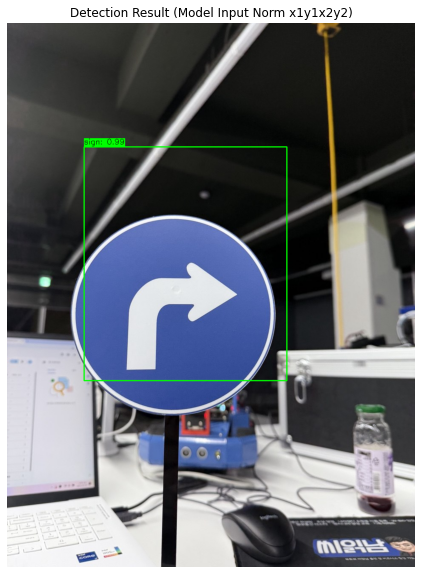

In [ ]:
import numpy as np
import time
import os
import sys
import random

# OpenCV Import 시도
try:
    import cv2
    CV2_AVAILABLE = True
    print("✅ OpenCV (cv2) 라이브러리 사용 가능")
except ImportError:
    CV2_AVAILABLE = False
    print("❌ OpenCV (cv2) 라이브러리 없음. 이미지 처리를 위해 설치가 필요합니다: pip install opencv-python")

# TensorRT 관련 import
try:
    import tensorrt as trt
    import pycuda.driver as cuda
    import pycuda.autoinit # CUDA 컨텍스트 자동 초기화
    TRT_AVAILABLE = True
    print("✅ TensorRT 라이브러리 사용 가능")
except ImportError as e:
    TRT_AVAILABLE = False
    print(f"❌ TensorRT 라이브러리 없음: {e}")

# 모델 경로 설정
model_path = "/home/soda/Project/python/notebook/seunghoproject/custom-train-yolo4_best.trt"
classes_path = "/home/soda/Project/python/notebook/seunghoproject/classes.names"
image_dir = "/home/soda/Project/python/notebook/seunghoproject/dataset2" # 이미지 디렉토리

class TensorRTInfer:
    """TensorRT 추론 클래스"""
    def __init__(self, engine_path):
        self.engine_path = engine_path
        self.engine = None
        self.context = None
        self.inputs = []
        self.outputs = []
        self.bindings = []
        self.stream = None
        self.input_shape = None
        self.output_shapes = [] # 출력 형태들 저장

    def load_engine(self):
        print(f"TensorRT 엔진 로딩 중: {self.engine_path}")
        TRT_LOGGER = trt.Logger(trt.Logger.WARNING)
        with open(self.engine_path, 'rb') as f:
            engine_data = f.read()
        runtime = trt.Runtime(TRT_LOGGER)
        self.engine = runtime.deserialize_cuda_engine(engine_data)
        if self.engine is None:
            print("❌ 엔진 로딩 실패")
            return False
        print("✅ 엔진 로딩 성공")
        self.context = self.engine.create_execution_context()
        self._setup_bindings()
        self.stream = cuda.Stream()
        return True

    def _setup_bindings(self):
        self.inputs = []
        self.outputs = []
        self.bindings = []
        self.output_shapes = []
        for binding in self.engine:
            binding_idx = self.engine.get_binding_index(binding)
            # get_binding_shape은 프로파일이 있는 경우 -1을 포함할 수 있음.
            # 여기서는 고정 배치 크기를 가정하고 진행하나, 동적 배치를 고려하려면 수정 필요.
            shape = self.engine.get_binding_shape(binding)
            # 만약 shape의 첫번째 차원이 -1 (동적 배치)이면, max_batch_size를 사용
            if shape[0] == -1:
                # 실제 컨텍스트에서 설정된 배치 크기를 사용하거나, max_batch_size 사용
                # 여기서는 간단히 max_batch_size로 가정 (실제로는 context.get_binding_shape(binding_idx) 사용 권장)
                shape = (self.engine.max_batch_size,) + shape[1:]

            size = trt.volume(shape) # shape 대신 self.engine.get_binding_shape(binding) * self.engine.max_batch_size
            dtype = trt.nptype(self.engine.get_binding_dtype(binding))
            device_mem = cuda.mem_alloc(size * dtype().itemsize)
            self.bindings.append(int(device_mem))
            if self.engine.binding_is_input(binding):
                host_mem = cuda.pagelocked_empty(size, dtype)
                self.inputs.append({'host': host_mem, 'device': device_mem, 'shape': shape, 'name': binding})
                self.input_shape = shape # (N, C, H, W)
                print(f"📥 입력 바인딩: {binding}, 형태: {shape}, 타입: {dtype}")
            else:
                host_mem = cuda.pagelocked_empty(size, dtype)
                self.outputs.append({'host': host_mem, 'device': device_mem, 'shape': shape, 'name': binding})
                self.output_shapes.append(shape)
                print(f"📤 출력 바인딩: {binding}, 형태: {shape}, 타입: {dtype}")

    def infer(self, input_data):
        np.copyto(self.inputs[0]['host'], input_data.ravel())
        cuda.memcpy_htod_async(self.inputs[0]['device'], self.inputs[0]['host'], self.stream)
        self.context.execute_async_v2(bindings=self.bindings, stream_handle=self.stream.handle)
        outputs_data = []
        for i, output_binding in enumerate(self.outputs):
            cuda.memcpy_dtoh_async(output_binding['host'], output_binding['device'], self.stream)
            # 출력 형태에 맞게 reshape. output_binding['shape']은 (N, ...) 형태
            reshaped_output = output_binding['host'].reshape(output_binding['shape'])
            outputs_data.append(reshaped_output.copy())
        self.stream.synchronize()
        return outputs_data

    def destroy(self):
        if self.stream: self.stream.synchronize()
        # GPU 메모리 명시적 해제 (선택적, PyCUDA가 컨텍스트 종료 시 처리)
        # for binding in self.inputs + self.outputs:
        #     if 'device' in binding and binding['device']:
        #         cuda.mem_free(binding['device'])
        if self.context: del self.context
        if self.engine: del self.engine
        print("TensorRT 리소스 해제 완료")

def preprocess_image_darknet_yolo(img_path, target_model_wh=(416, 416)): # target_size -> target_model_wh로 변경
    """
    Darknet YOLO 모델 입력에 맞게 이미지 전처리 (letterbox 방식).
    target_model_wh: (width, height) - 모델의 입력 너비, 높이
    반환값: 전처리된 이미지 텐서, 원본 이미지, 패딩 정보 (dw, dh, new_w, new_h, original_w, original_h, scale)
    """
    if not CV2_AVAILABLE:
        print("❌ OpenCV가 없어 이미지 전처리를 수행할 수 없습니다.")
        return None, None, None

    original_image = cv2.imread(img_path)
    if original_image is None:
        print(f"❌ 이미지 파일을 읽을 수 없습니다: {img_path}")
        return None, None, None

    img_h, img_w, _ = original_image.shape
    target_w, target_h = target_model_wh # 여기서 target_model_wh를 사용

    scale = min(target_w / img_w, target_h / img_h)
    new_w = int(img_w * scale)
    new_h = int(img_h * scale)

    resized_img = cv2.resize(original_image, (new_w, new_h), interpolation=cv2.INTER_LINEAR)

    padded_img = np.full((target_h, target_w, 3), 128, dtype=np.uint8) # target_h, target_w 사용
    dw = (target_w - new_w) // 2
    dh = (target_h - new_h) // 2
    padded_img[dh:dh + new_h, dw:dw + new_w, :] = resized_img

    rgb_img = cv2.cvtColor(padded_img, cv2.COLOR_BGR2RGB)
    normalized_img = rgb_img.astype(np.float32) / 255.0
    transposed_img = np.transpose(normalized_img, (2, 0, 1))
    input_tensor = np.expand_dims(transposed_img, axis=0)

    # padding_info 반환 시 original_w, original_h는 원본 이미지의 크기인 img_w, img_h를 사용
    padding_info = (dw, dh, new_w, new_h, img_w, img_h, scale)
    return input_tensor, original_image, padding_info

def postprocess_yolo_detections(outputs, padding_info, original_image_shape, target_model_wh=(416,416), conf_thresh=0.25, iou_thresh=0.45, num_classes=1):
    """
    YOLOv4 (TRT) 출력을 디코딩.
    가설: 출력은 모델 입력 크기(target_model_wh) 기준 0-1 정규화된 (x1,y1,x2,y2).
    outputs: TRT 엔진의 출력 리스트.
    padding_info: (dw, dh, new_w, new_h, original_w_from_pad_info, original_h_from_pad_info, scale) from preprocess
    original_image_shape: (height, width) of the actual original image (검증용으로 사용 가능)
    target_model_wh: (width, height) of the model input
    """
    raw_detections = []

    boxes_data_output = outputs[0]
    confidences_data_output = outputs[1]

    model_w, model_h = target_model_wh # 모델 입력 너비, 높이 (예: 416, 416)
    # padding_info에서 dw, dh, scale 등을 가져옴
    dw, dh, new_w_scaled, new_h_scaled, original_w_actual, original_h_actual, scale = padding_info
    # original_image_shape과 original_w_actual, original_h_actual은 같아야 함

    normalized_boxes = boxes_data_output[0][:, 0, :]
    confidences = confidences_data_output[0][:, 0]

    for i in range(normalized_boxes.shape[0]):
        confidence = confidences[i]

        if confidence >= conf_thresh:
            x1_norm, y1_norm, x2_norm, y2_norm = normalized_boxes[i]
            print(f"Debug Start for Conf {confidence:.2f}:")
            print(f"  Norm Coords (model_input_relative): [{x1_norm:.4f}, {y1_norm:.4f}, {x2_norm:.4f}, {y2_norm:.4f}]")

            if np.isnan(x1_norm) or np.isinf(x1_norm) or \
               np.isnan(y1_norm) or np.isinf(y1_norm) or \
               np.isnan(x2_norm) or np.isinf(x2_norm) or \
               np.isnan(y2_norm) or np.isinf(y2_norm):
                continue

            # 1. 모델 입력(target_model_wh) 내에서의 절대 좌표로 변환
            abs_x1_model_input = x1_norm * model_w
            abs_y1_model_input = y1_norm * model_h
            abs_x2_model_input = x2_norm * model_w
            abs_y2_model_input = y2_norm * model_h
            print(f"  Abs Coords in Model Input ({model_w}x{model_h}): [{abs_x1_model_input:.1f}, {abs_y1_model_input:.1f}, {abs_x2_model_input:.1f}, {abs_y2_model_input:.1f}]")

            # 2. 원본 이미지 좌표로 복원 (letterbox 패딩 제거 및 스케일 복원)
            #   패딩된 이미지(model_w x model_h)에서 dw, dh를 빼서 리사이즈된 이미지 영역 좌표로.
            #   그 다음 1/scale 을 곱해서 원본 이미지 좌표로.

            print(f"  Padding info for calc: dw={dw}, dh={dh}, scale={scale:.4f}")
            print(f"  Original image actual size (w,h): {original_w_actual}, {original_h_actual}")

            orig_x1 = (abs_x1_model_input - dw) / scale
            orig_y1 = (abs_y1_model_input - dh) / scale
            orig_x2 = (abs_x2_model_input - dw) / scale
            orig_y2 = (abs_y2_model_input - dh) / scale
            print(f"  Orig Coords after unpad/unscale: [{orig_x1:.1f}, {orig_y1:.1f}, {orig_x2:.1f}, {orig_y2:.1f}]")



            # 원본 이미지 경계 내로 클리핑
            orig_x1_clipped = max(0, min(orig_x1, original_w_actual -1))
            orig_y1_clipped = max(0, min(orig_y1, original_h_actual -1))
            orig_x2_clipped = max(0, min(orig_x2, original_w_actual -1))
            orig_y2_clipped = max(0, min(orig_y2, original_h_actual -1))

            if orig_x2_clipped > orig_x1_clipped and orig_y2_clipped > orig_y1_clipped:
                 raw_detections.append([orig_x1_clipped, orig_y1_clipped, orig_x2_clipped, orig_y2_clipped, confidence, 0])

    final_detections = apply_nms(raw_detections, iou_thresh)
    return final_detections


def test_tensorrt_model():
    print("=" * 60)
    print("TensorRT 모델 실제 이미지 테스트 및 시각화 (모델 입력 기준 정규화 x1y1x2y2 가설 적용)")
    print("=" * 60)

    if not TRT_AVAILABLE:
        print("TensorRT를 사용할 수 없어 테스트를 중단합니다.")
        return False
    if not CV2_AVAILABLE:
        print("OpenCV를 사용할 수 없어 이미지 테스트를 중단합니다.")
        return False

    # 1. 모델 파일 확인
    print(f"1. 모델 파일 확인: {model_path}")
    if not os.path.exists(model_path):
        print("   ❌ 모델 파일이 존재하지 않음")
        return False
    file_size_mb = os.path.getsize(model_path) / (1024 * 1024)
    print(f"   ✅ 파일 존재 (크기: {file_size_mb:.2f} MB)")

    # 2. 클래스 파일 확인
    class_names = []
    print(f"\n2. 클래스 파일 확인: {classes_path}")
    if os.path.exists(classes_path):
        with open(classes_path, 'r') as f:
            class_names = [line.strip() for line in f.readlines()]
        print(f"   ✅ 클래스 파일 존재 ({len(class_names)}개 클래스: {class_names})")
        num_classes = len(class_names)
    else:
        print(f"   ⚠️ 클래스 파일이 존재하지 않음: {classes_path}. num_classes=1, class_names=['object']로 가정합니다.")
        num_classes = 1
        class_names = ['object'] # 기본 클래스 이름 설정

    # 3. TensorRT 엔진 로딩 시도
    print(f"\n3. TensorRT 엔진 로딩 시도")
    infer_engine = TensorRTInfer(model_path)
    try:
        start_time = time.time()
        if not infer_engine.load_engine():
            return False
        load_duration = time.time() - start_time
        print(f"   ⏱️  로딩 시간: {load_duration:.3f}초")
    except Exception as e:
        print(f"   ❌ 엔진 로딩 실패: {str(e)}")
        if hasattr(infer_engine, 'destroy'): infer_engine.destroy()
        return False

    # 4. 실제 이미지 추론 및 시각화 테스트
    processed_image_for_display = None
    try:
        # image_dir는 "/home/soda/Project/python/notebook/seunghoproject/dataset2" 로 설정됨
        image_files = [f for f in os.listdir(image_dir) if f.lower().endswith(('.png', '.jpg', '.jpeg')) and not os.path.isdir(os.path.join(image_dir, f))]

        if not image_files:
            print(f"   ❌ 테스트할 이미지가 디렉토리에 없습니다: {image_dir}")
            if hasattr(infer_engine, 'destroy'): infer_engine.destroy()
            return False

        image_name_to_test = random.choice(image_files)
        image_path_to_test = os.path.join(image_dir, image_name_to_test)

        print(f"   🖼️ 테스트 이미지: {image_path_to_test}")
        if not os.path.exists(image_path_to_test):
            print(f"   ❌ 테스트 이미지를 찾을 수 없습니다: {image_path_to_test}")
            if hasattr(infer_engine, 'destroy'): infer_engine.destroy()
            return False

        model_input_h = infer_engine.input_shape[2]
        model_input_w = infer_engine.input_shape[3]
        target_model_wh = (model_input_w, model_input_h)
        print(f"   모델 입력 크기 (W, H): {target_model_wh}")

        # 이미지 전처리 시 padding_info를 다시 받아야 함
        input_data, original_image, padding_info = preprocess_image_darknet_yolo(image_path_to_test, target_model_wh=target_model_wh)
        if input_data is None or original_image is None:
            print("   ❌ 이미지 전처리 실패")
            if hasattr(infer_engine, 'destroy'): infer_engine.destroy()
            return False
        print(f"   📥 전처리된 입력 데이터 형태: {input_data.shape}, 타입: {input_data.dtype}")

        start_time = time.time()
        outputs = infer_engine.infer(input_data)
        inference_time = time.time() - start_time

        print(f"   ✅ 추론 성공! ⏱️ 추론 시간: {inference_time*1000:.2f}ms")
        if inference_time > 0:
            print(f"   🎯 예상 FPS: {1.0/inference_time:.1f}")

        # 후처리 (새로운 가설 적용: 모델 입력 기준 정규화 (x1,y1,x2,y2) -> 패딩 정보로 원본 복원)
        detections = postprocess_yolo_detections(outputs,
                                                 padding_info=padding_info,
                                                 original_image_shape=original_image.shape[:2],
                                                 target_model_wh=target_model_wh,
                                                 conf_thresh=0.25,
                                                 iou_thresh=0.45,
                                                 num_classes=num_classes)

        if detections:
            print(f"   ✅ {len(detections)}개의 객체 탐지 (NMS 적용 후, conf > 0.25):")
            for i, det in enumerate(detections[:10]):
                print(f"     - 객체 {i+1}: Box(orig)=[{int(det[0])},{int(det[1])},{int(det[2])},{int(det[3])}], Conf={det[4]:.2f}, ClassID={int(det[5])}")

            processed_image_for_display = draw_detections(original_image, detections, class_names)
        else:
            print(f"   ❌ 객체 탐지 실패 (NMS 적용 후, conf > 0.25)")
            if outputs and len(outputs) >= 2:
                print(f"   🔍 출력 0 (boxes) 일부 값 (처음 5개, flatten): {outputs[0].flatten()[:5]}")
                print(f"   🔍 출력 1 (confs) 일부 값 (처음 5개, flatten): {outputs[1].flatten()[:5]}")
            processed_image_for_display = original_image

    except Exception as e:
        print(f"   ❌ 테스트 중 예외 발생: {str(e)}")
        import traceback
        traceback.print_exc()
        if 'original_image' in locals() and original_image is not None:
            processed_image_for_display = original_image
    finally:
        if hasattr(infer_engine, 'destroy'):
             infer_engine.destroy()

    print("\n" + "=" * 60)
    print("🎉 TensorRT 모델 실제 이미지 테스트 완료!")
    print("=" * 60)

    if MATPLOTLIB_AVAILABLE and processed_image_for_display is not None:
        plt.figure(figsize=(10, 10))
        plt.imshow(cv2.cvtColor(processed_image_for_display, cv2.COLOR_BGR2RGB))
        plt.title("Detection Result (Model Input Norm x1y1x2y2)")
        plt.axis('off')
        plt.show()
    elif processed_image_for_display is not None:
        print("Matplotlib이 없어 셀 내 이미지 표시는 생략합니다.")

    return True

def check_system_compatibility():
    """시스템 호환성 체크"""
    print("\n🔧 시스템 호환성 체크")
    print("-" * 30)
    packages_to_check = ['tensorrt', 'pycuda', 'numpy', 'opencv-python']
    for package in packages_to_check:
        try:
            module_name = package.replace('-', '_') if package != 'opencv-python' else 'cv2'
            __import__(module_name)
            print(f"   ✅ {package}")
        except ImportError:
            print(f"   ❌ {package} (설치 필요: pip install {package})")

if __name__ == "__main__":
    check_system_compatibility()
    if TRT_AVAILABLE:
        test_tensorrt_model()
    else:
        print("\nTensorRT 사용이 불가능하여 테스트를 진행할 수 없습니다.")
        # test_alternative_methods() # 필요한 경우 주석 해제

# 바운딩 박스 테스트

✅ OpenCV (cv2) 라이브러리 사용 가능
✅ Matplotlib 라이브러리 사용 가능
✅ TensorRT 라이브러리 사용 가능

🔧 시스템 호환성 체크
------------------------------
   ✅ tensorrt
   ✅ pycuda
   ✅ numpy
   ✅ opencv-python
   ✅ matplotlib
TensorRT 모델 실제 이미지 테스트 및 시각화 (모델 입력 기준 정규화 x1y1x2y2 가설 적용)
1. 모델 파일 확인: /home/soda/Project/python/notebook/seunghoproject/custom-train-yolo4_best.trt
   ✅ 파일 존재 (크기: 560.29 MB)

2. 클래스 파일 확인: /home/soda/Project/python/notebook/seunghoproject/classes.names
   ✅ 클래스 파일 존재 (1개 클래스: ['sign'])

3. TensorRT 엔진 로딩 시도
TensorRT 엔진 로딩 중: /home/soda/Project/python/notebook/seunghoproject/custom-train-yolo4_best.trt
✅ 엔진 로딩 성공
📥 입력 바인딩: input, 형태: (1, 3, 416, 416), 타입: <class 'numpy.float32'>
📤 출력 바인딩: output, 형태: (1, 10647, 1, 4), 타입: <class 'numpy.float32'>
📤 출력 바인딩: 1980, 형태: (1, 10647, 1), 타입: <class 'numpy.float32'>
   ⏱️  로딩 시간: 0.626초
   🖼️ 테스트 이미지: /home/soda/Project/python/notebook/seunghoproject/dataset2/6179389875523011633.jpg
   모델 입력 크기 (W, H): (416, 416)
   📥 전처리된 입력 데이터 형태: (1, 3, 416, 416), 타입

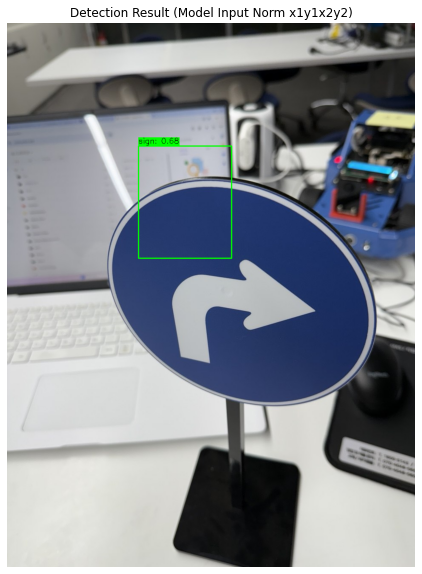

In [ ]:
import numpy as np
import time
import os
import sys
import random

# OpenCV Import 시도
try:
    import cv2
    CV2_AVAILABLE = True
    print("✅ OpenCV (cv2) 라이브러리 사용 가능")
except ImportError:
    CV2_AVAILABLE = False
    print("❌ OpenCV (cv2) 라이브러리 없음. 이미지 처리를 위해 설치가 필요합니다: pip install opencv-python")

# Matplotlib Import 시도 (Jupyter/Colab에서 이미지 표시용)
try:
    import matplotlib.pyplot as plt
    MATPLOTLIB_AVAILABLE = True
    print("✅ Matplotlib 라이브러리 사용 가능")
except ImportError:
    MATPLOTLIB_AVAILABLE = False
    print("⚠️ Matplotlib 라이브러리 없음. 이미지 시각화를 위해 설치를 권장합니다: pip install matplotlib")


# TensorRT 관련 import
try:
    import tensorrt as trt
    import pycuda.driver as cuda
    import pycuda.autoinit # CUDA 컨텍스트 자동 초기화
    TRT_AVAILABLE = True
    print("✅ TensorRT 라이브러리 사용 가능")
except ImportError as e:
    TRT_AVAILABLE = False
    print(f"❌ TensorRT 라이브러리 없음: {e}")

# 모델 경로 설정
model_path = "/home/soda/Project/python/notebook/seunghoproject/custom-train-yolo4_best.trt"
classes_path = "/home/soda/Project/python/notebook/seunghoproject/classes.names"
image_dir = "/home/soda/Project/python/notebook/seunghoproject/dataset2"

# --- 이전 TensorRTInfer 클래스 코드는 동일하게 유지 ---
class TensorRTInfer:
    """TensorRT 추론 클래스"""
    def __init__(self, engine_path):
        self.engine_path = engine_path
        self.engine = None
        self.context = None
        self.inputs = []
        self.outputs = []
        self.bindings = []
        self.stream = None
        self.input_shape = None
        self.output_shapes = []

    def load_engine(self):
        print(f"TensorRT 엔진 로딩 중: {self.engine_path}")
        TRT_LOGGER = trt.Logger(trt.Logger.WARNING)
        with open(self.engine_path, 'rb') as f:
            engine_data = f.read()
        runtime = trt.Runtime(TRT_LOGGER)
        self.engine = runtime.deserialize_cuda_engine(engine_data)
        if self.engine is None:
            print("❌ 엔진 로딩 실패")
            return False
        print("✅ 엔진 로딩 성공")
        self.context = self.engine.create_execution_context()
        self._setup_bindings()
        self.stream = cuda.Stream()
        return True

    def _setup_bindings(self):
        self.inputs = []
        self.outputs = []
        self.bindings = []
        self.output_shapes = []
        for binding in self.engine:
            binding_idx = self.engine.get_binding_index(binding)
            shape = self.engine.get_binding_shape(binding)
            if shape[0] == -1 : # 동적 배치 크기 처리 (max_batch_size 사용)
                 # context가 생성된 후라면 context.get_binding_shape(binding_idx) 사용 가능
                 # 여기서는 단순화를 위해 engine의 max_batch_size 사용
                 shape = (self.engine.max_batch_size,) + shape[1:]

            size = trt.volume(shape)
            dtype = trt.nptype(self.engine.get_binding_dtype(binding))
            device_mem = cuda.mem_alloc(size * dtype().itemsize)
            self.bindings.append(int(device_mem))

            if self.engine.binding_is_input(binding):
                host_mem = cuda.pagelocked_empty(size, dtype)
                self.inputs.append({'host': host_mem, 'device': device_mem, 'shape': shape, 'name': binding})
                self.input_shape = shape
                print(f"📥 입력 바인딩: {binding}, 형태: {shape}, 타입: {dtype}")
            else:
                host_mem = cuda.pagelocked_empty(size, dtype)
                self.outputs.append({'host': host_mem, 'device': device_mem, 'shape': shape, 'name': binding})
                self.output_shapes.append(shape)
                print(f"📤 출력 바인딩: {binding}, 형태: {shape}, 타입: {dtype}")

    def infer(self, input_data):
        np.copyto(self.inputs[0]['host'], input_data.ravel())
        cuda.memcpy_htod_async(self.inputs[0]['device'], self.inputs[0]['host'], self.stream)
        self.context.execute_async_v2(bindings=self.bindings, stream_handle=self.stream.handle)
        outputs_data = []
        for i, output_binding in enumerate(self.outputs):
            cuda.memcpy_dtoh_async(output_binding['host'], output_binding['device'], self.stream)
            # 출력 형태에 맞게 reshape. output_binding['shape']은 (N, ...) 형태
            # host 메모리는 1D 이므로, 추론 후 reshape 필요
            reshaped_output = output_binding['host'].reshape(output_binding['shape'])
            outputs_data.append(reshaped_output.copy())
        self.stream.synchronize()
        return outputs_data

    def destroy(self):
        if self.stream: self.stream.synchronize()
        if self.context: del self.context
        if self.engine: del self.engine
        print("TensorRT 리소스 해제 완료")
# --- TensorRTInfer 클래스 코드 끝 ---

def preprocess_image_darknet_yolo(img_path, target_model_wh=(416, 416)): # target_size -> target_model_wh로 변경
    """
    Darknet YOLO 모델 입력에 맞게 이미지 전처리 (letterbox 방식).
    target_model_wh: (width, height) - 모델의 입력 너비, 높이
    반환값: 전처리된 이미지 텐서, 원본 이미지, 패딩 정보 (dw, dh, new_w, new_h, original_w, original_h, scale)
    """
    if not CV2_AVAILABLE:
        print("❌ OpenCV가 없어 이미지 전처리를 수행할 수 없습니다.")
        return None, None, None

    original_image = cv2.imread(img_path)
    if original_image is None:
        print(f"❌ 이미지 파일을 읽을 수 없습니다: {img_path}")
        return None, None, None

    img_h, img_w, _ = original_image.shape
    target_w, target_h = target_model_wh # 여기서 target_model_wh를 사용

    scale = min(target_w / img_w, target_h / img_h)
    new_w = int(img_w * scale)
    new_h = int(img_h * scale)

    resized_img = cv2.resize(original_image, (new_w, new_h), interpolation=cv2.INTER_LINEAR)

    padded_img = np.full((target_h, target_w, 3), 128, dtype=np.uint8) # target_h, target_w 사용
    dw = (target_w - new_w) // 2
    dh = (target_h - new_h) // 2
    padded_img[dh:dh + new_h, dw:dw + new_w, :] = resized_img

    rgb_img = cv2.cvtColor(padded_img, cv2.COLOR_BGR2RGB)
    normalized_img = rgb_img.astype(np.float32) / 255.0
    transposed_img = np.transpose(normalized_img, (2, 0, 1))
    input_tensor = np.expand_dims(transposed_img, axis=0)

    # padding_info 반환 시 original_w, original_h는 원본 이미지의 크기인 img_w, img_h를 사용
    padding_info = (dw, dh, new_w, new_h, img_w, img_h, scale)
    return input_tensor, original_image, padding_info

def iou(box1, box2):
    """박스 간의 IoU 계산 (x1, y1, x2, y2) 형식"""
    x1_inter = max(box1[0], box2[0])
    y1_inter = max(box1[1], box2[1])
    x2_inter = min(box1[2], box2[2])
    y2_inter = min(box1[3], box2[3])

    inter_area = max(0, x2_inter - x1_inter) * max(0, y2_inter - y1_inter)
    box1_area = (box1[2] - box1[0]) * (box1[3] - box1[1])
    box2_area = (box2[2] - box2[0]) * (box2[3] - box2[1])
    union_area = box1_area + box2_area - inter_area
    return inter_area / union_area if union_area > 0 else 0

def apply_nms(detections, iou_thresh=0.45):
    """
    Non-Maximum Suppression 적용.
    detections: 리스트 [[x1, y1, x2, y2, confidence, class_id], ...]
    """
    if not detections:
        return []

    # 신뢰도 순으로 정렬
    detections.sort(key=lambda x: x[4], reverse=True)

    final_detections = []
    while detections:
        best_detection = detections.pop(0)
        final_detections.append(best_detection)

        # 남은 detection들과 best_detection의 IoU 비교
        remaining_detections = []
        for det in detections:
            if det[5] == best_detection[5]: # 같은 클래스일 때만 NMS
                if iou(best_detection[:4], det[:4]) < iou_thresh:
                    remaining_detections.append(det)
            else: # 다른 클래스면 유지
                remaining_detections.append(det)
        detections = remaining_detections

    return final_detections

def postprocess_yolo_detections(outputs, padding_info, original_image_shape, target_model_wh=(416,416), conf_thresh=0.25, iou_thresh=0.45, num_classes=1):
    """
    YOLOv4 (TRT) 출력을 디코딩.
    가설: 출력은 모델 입력 크기(target_model_wh) 기준 0-1 정규화된 (x1,y1,x2,y2).
    outputs: TRT 엔진의 출력 리스트.
    padding_info: (dw, dh, new_w_scaled, new_h_scaled, original_w_actual, original_h_actual, scale) from preprocess
    original_image_shape: (height, width) of the actual original image (주로 검증용)
    target_model_wh: (width, height) of the model input
    """
    raw_detections = []

    boxes_data_output = outputs[0]  # Shape: (1, num_predictions, 1, 4)
    confidences_data_output = outputs[1] # Shape: (1, num_predictions, 1)

    model_w, model_h = target_model_wh # 모델 입력 너비, 높이 (예: 416, 416)
    # padding_info에서 dw, dh, scale 등을 가져옴
    dw, dh, new_w_scaled, new_h_scaled, original_w_actual, original_h_actual, scale = padding_info

    normalized_boxes = boxes_data_output[0][:, 0, :]  # Shape: (num_predictions, 4)
    confidences = confidences_data_output[0][:, 0]    # Shape: (num_predictions,)

    for i in range(normalized_boxes.shape[0]):
        confidence = confidences[i]

        if confidence >= conf_thresh:
            x1_norm, y1_norm, x2_norm, y2_norm = normalized_boxes[i]
            # print(f"Debug: Norm Coords (model_input_relative): [{x1_norm:.4f}, {y1_norm:.4f}, {x2_norm:.4f}, {y2_norm:.4f}], Conf: {confidence:.2f}")

            if np.isnan(x1_norm) or np.isinf(x1_norm) or \
               np.isnan(y1_norm) or np.isinf(y1_norm) or \
               np.isnan(x2_norm) or np.isinf(x2_norm) or \
               np.isnan(y2_norm) or np.isinf(y2_norm):
                # print(f"경고: 유효하지 않은 좌표값 건너뜀: {[x1_norm, y1_norm, x2_norm, y2_norm]}")
                continue

            # 1. 모델 입력(target_model_wh) 내에서의 절대 좌표로 변환
            abs_x1_model_input = x1_norm * model_w
            abs_y1_model_input = y1_norm * model_h
            abs_x2_model_input = x2_norm * model_w
            abs_y2_model_input = y2_norm * model_h
            # print(f"Debug: Abs Coords in Model Input ({model_w}x{model_h}): [{abs_x1_model_input:.1f}, {abs_y1_model_input:.1f}, {abs_x2_model_input:.1f}, {abs_y2_model_input:.1f}]")

            # 2. 원본 이미지 좌표로 복원 (letterbox 패딩 제거 및 스케일 복원)
            orig_x1 = (abs_x1_model_input - dw) / scale
            orig_y1 = (abs_y1_model_input - dh) / scale
            orig_x2 = (abs_x2_model_input - dw) / scale
            orig_y2 = (abs_y2_model_input - dh) / scale
            # print(f"Debug: Padding info: dw={dw}, dh={dh}, new_w_s={new_w_scaled}, new_h_s={new_h_scaled}, orig_w_act={original_w_actual}, orig_h_act={original_h_actual} scale={scale:.4f}")
            # print(f"Debug: Orig Coords before clip: [{orig_x1:.1f}, {orig_y1:.1f}, {orig_x2:.1f}, {orig_y2:.1f}]")

            # 원본 이미지 경계 내로 클리핑
            orig_x1_clipped = max(0, min(orig_x1, original_w_actual - 1))
            orig_y1_clipped = max(0, min(orig_y1, original_h_actual - 1))
            orig_x2_clipped = max(0, min(orig_x2, original_w_actual - 1))
            orig_y2_clipped = max(0, min(orig_y2, original_h_actual - 1))

            if orig_x2_clipped > orig_x1_clipped and orig_y2_clipped > orig_y1_clipped: # 유효한 박스인지 확인
                 raw_detections.append([orig_x1_clipped, orig_y1_clipped, orig_x2_clipped, orig_y2_clipped, confidence, 0]) # class_id 0

    # NMS 적용
    final_detections = apply_nms(raw_detections, iou_thresh)
    return final_detections

def draw_detections(image, detections, class_names):
    """탐지된 객체들을 이미지에 그립니다."""
    if not CV2_AVAILABLE: return image # OpenCV 없으면 원본 반환

    img_copy = image.copy()
    for det in detections:
        x1, y1, x2, y2, conf, class_id = det
        x1, y1, x2, y2 = int(x1), int(y1), int(x2), int(y2)

        # 클래스 이름 가져오기
        try:
            label = class_names[int(class_id)]
        except (IndexError, TypeError):
            label = f"ClassID:{int(class_id)}"

        # 박스 그리기 (초록색)
        cv2.rectangle(img_copy, (x1, y1), (x2, y2), (0, 255, 0), 2)

        # 텍스트 준비
        text = f"{label}: {conf:.2f}"

        # 텍스트 배경 박스
        (text_width, text_height), baseline = cv2.getTextSize(text, cv2.FONT_HERSHEY_SIMPLEX, 0.6, 1)
        cv2.rectangle(img_copy, (x1, y1 - text_height - baseline), (x1 + text_width, y1), (0, 255, 0), -1) # 배경 채우기

        # 텍스트 쓰기 (검은색)
        cv2.putText(img_copy, text, (x1, y1 - baseline), cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0, 0, 0), 1)

    return img_copy

def test_tensorrt_model():
    print("=" * 60)
    print("TensorRT 모델 실제 이미지 테스트 및 시각화 (모델 입력 기준 정규화 x1y1x2y2 가설 적용)")
    print("=" * 60)

    if not TRT_AVAILABLE:
        print("TensorRT를 사용할 수 없어 테스트를 중단합니다.")
        return False
    if not CV2_AVAILABLE:
        print("OpenCV를 사용할 수 없어 이미지 테스트를 중단합니다.")
        return False

    # 1. 모델 파일 확인
    print(f"1. 모델 파일 확인: {model_path}")
    if not os.path.exists(model_path):
        print("   ❌ 모델 파일이 존재하지 않음")
        return False
    file_size_mb = os.path.getsize(model_path) / (1024 * 1024)
    print(f"   ✅ 파일 존재 (크기: {file_size_mb:.2f} MB)")

    # 2. 클래스 파일 확인
    class_names = []
    print(f"\n2. 클래스 파일 확인: {classes_path}")
    if os.path.exists(classes_path):
        with open(classes_path, 'r') as f:
            class_names = [line.strip() for line in f.readlines()]
        print(f"   ✅ 클래스 파일 존재 ({len(class_names)}개 클래스: {class_names})")
        num_classes = len(class_names)
    else:
        print(f"   ⚠️ 클래스 파일이 존재하지 않음: {classes_path}. num_classes=1, class_names=['object']로 가정합니다.")
        num_classes = 1
        class_names = ['object'] # 기본 클래스 이름 설정

    # 3. TensorRT 엔진 로딩 시도
    print(f"\n3. TensorRT 엔진 로딩 시도")
    infer_engine = TensorRTInfer(model_path)
    try:
        start_time = time.time()
        if not infer_engine.load_engine():
            return False
        load_duration = time.time() - start_time
        print(f"   ⏱️  로딩 시간: {load_duration:.3f}초")
    except Exception as e:
        print(f"   ❌ 엔진 로딩 실패: {str(e)}")
        if hasattr(infer_engine, 'destroy'): infer_engine.destroy()
        return False

    # 4. 실제 이미지 추론 및 시각화 테스트
    processed_image_for_display = None
    try:
        # image_dir는 "/home/soda/Project/python/notebook/seunghoproject/dataset2" 로 설정됨
        image_files = [f for f in os.listdir(image_dir) if f.lower().endswith(('.png', '.jpg', '.jpeg')) and not os.path.isdir(os.path.join(image_dir, f))]

        if not image_files:
            print(f"   ❌ 테스트할 이미지가 디렉토리에 없습니다: {image_dir}")
            if hasattr(infer_engine, 'destroy'): infer_engine.destroy()
            return False

        image_name_to_test = random.choice(image_files)
        image_path_to_test = os.path.join(image_dir, image_name_to_test)

        print(f"   🖼️ 테스트 이미지: {image_path_to_test}")
        if not os.path.exists(image_path_to_test):
            print(f"   ❌ 테스트 이미지를 찾을 수 없습니다: {image_path_to_test}")
            if hasattr(infer_engine, 'destroy'): infer_engine.destroy()
            return False

        model_input_h = infer_engine.input_shape[2]
        model_input_w = infer_engine.input_shape[3]
        target_model_wh = (model_input_w, model_input_h)
        print(f"   모델 입력 크기 (W, H): {target_model_wh}")

        # 이미지 전처리 시 padding_info를 다시 받아야 함
        input_data, original_image, padding_info = preprocess_image_darknet_yolo(image_path_to_test, target_model_wh=target_model_wh)
        if input_data is None or original_image is None:
            print("   ❌ 이미지 전처리 실패")
            if hasattr(infer_engine, 'destroy'): infer_engine.destroy()
            return False
        print(f"   📥 전처리된 입력 데이터 형태: {input_data.shape}, 타입: {input_data.dtype}")

        start_time = time.time()
        outputs = infer_engine.infer(input_data)
        inference_time = time.time() - start_time

        print(f"   ✅ 추론 성공! ⏱️ 추론 시간: {inference_time*1000:.2f}ms")
        if inference_time > 0:
            print(f"   🎯 예상 FPS: {1.0/inference_time:.1f}")

        # 후처리 (새로운 가설 적용: 모델 입력 기준 정규화 (x1,y1,x2,y2) -> 패딩 정보로 원본 복원)
        detections = postprocess_yolo_detections(outputs,
                                                 padding_info=padding_info,
                                                 original_image_shape=original_image.shape[:2],
                                                 target_model_wh=target_model_wh,
                                                 conf_thresh=0.25,
                                                 iou_thresh=0.45,
                                                 num_classes=num_classes)

        if detections:
            print(f"   ✅ {len(detections)}개의 객체 탐지 (NMS 적용 후, conf > 0.25):")
            for i, det in enumerate(detections[:10]):
                print(f"     - 객체 {i+1}: Box(orig)=[{int(det[0])},{int(det[1])},{int(det[2])},{int(det[3])}], Conf={det[4]:.2f}, ClassID={int(det[5])}")

            processed_image_for_display = draw_detections(original_image, detections, class_names)
        else:
            print(f"   ❌ 객체 탐지 실패 (NMS 적용 후, conf > 0.25)")
            if outputs and len(outputs) >= 2:
                print(f"   🔍 출력 0 (boxes) 일부 값 (처음 5개, flatten): {outputs[0].flatten()[:5]}")
                print(f"   🔍 출력 1 (confs) 일부 값 (처음 5개, flatten): {outputs[1].flatten()[:5]}")
            processed_image_for_display = original_image

    except Exception as e:
        print(f"   ❌ 테스트 중 예외 발생: {str(e)}")
        import traceback
        traceback.print_exc()
        if 'original_image' in locals() and original_image is not None:
            processed_image_for_display = original_image
    finally:
        if hasattr(infer_engine, 'destroy'):
             infer_engine.destroy()

    print("\n" + "=" * 60)
    print("🎉 TensorRT 모델 실제 이미지 테스트 완료!")
    print("=" * 60)

    if MATPLOTLIB_AVAILABLE and processed_image_for_display is not None:
        plt.figure(figsize=(10, 10))
        plt.imshow(cv2.cvtColor(processed_image_for_display, cv2.COLOR_BGR2RGB))
        plt.title("Detection Result (Model Input Norm x1y1x2y2)")
        plt.axis('off')
        plt.show()
    elif processed_image_for_display is not None:
        print("Matplotlib이 없어 셀 내 이미지 표시는 생략합니다.")

    return True


def check_system_compatibility():
    print("\n🔧 시스템 호환성 체크")
    print("-" * 30)
    packages_to_check = ['tensorrt', 'pycuda', 'numpy', 'opencv-python', 'matplotlib']
    for package in packages_to_check:
        try:
            module_name = package.replace('-', '_') if package not in ['opencv-python', 'matplotlib'] else ('cv2' if package == 'opencv-python' else 'matplotlib')
            __import__(module_name)
            print(f"   ✅ {package}")
        except ImportError:
            print(f"   ❌ {package} (설치 필요: pip install {package})")

if __name__ == "__main__":
    check_system_compatibility()
    if TRT_AVAILABLE and CV2_AVAILABLE : # OpenCV도 필수
        test_tensorrt_model()
    else:
        print("\nTensorRT 또는 OpenCV 사용이 불가능하여 테스트를 진행할 수 없습니다.")

# 완벽한 박스 테스트

TensorRT YOLOv4 간편 테스트 시작
클래스: ['sign']
모델 로드 완료. 입력 크기 (W,H): (416, 416)
테스트할 이미지 3개 선택: ['/home/soda/Project/python/notebook/seunghoproject/dataset2/capture_2025-05-29_20:43:20.jpg', '/home/soda/Project/python/notebook/seunghoproject/dataset2/6179389875523011638.jpg', '/home/soda/Project/python/notebook/seunghoproject/dataset2/6179389875523011637.jpg']

--- 이미지 처리 중: /home/soda/Project/python/notebook/seunghoproject/dataset2/capture_2025-05-29_20:43:20.jpg ---
탐지된 객체 수: 1
  Box: [81,46,171,168], Conf: 0.99


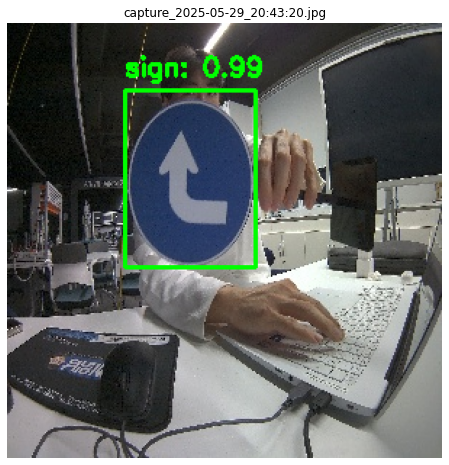


--- 이미지 처리 중: /home/soda/Project/python/notebook/seunghoproject/dataset2/6179389875523011638.jpg ---
탐지된 객체 수: 1
  Box: [181,291,658,841], Conf: 0.99


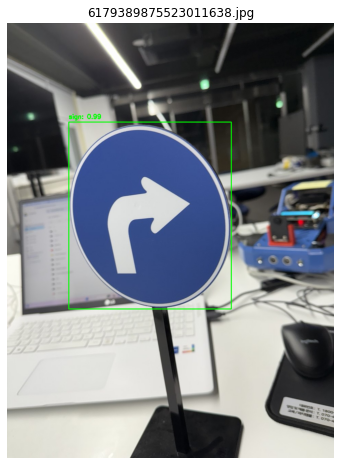


--- 이미지 처리 중: /home/soda/Project/python/notebook/seunghoproject/dataset2/6179389875523011637.jpg ---
탐지된 객체 수: 1
  Box: [147,314,747,909], Conf: 0.99


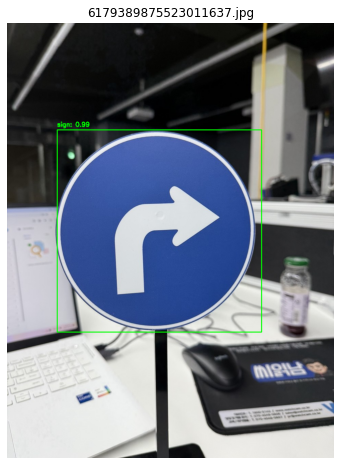

TensorRT 모델 리소스 해제 완료.


In [ ]:
import numpy as np
import tensorrt as trt
import pycuda.driver as cuda
import pycuda.autoinit # CUDA 컨텍스트 자동 초기화 (필수)
import cv2
import os
import random
import matplotlib.pyplot as plt

# --- 경로 설정 ---
MODEL_PATH = "/home/soda/Project/python/notebook/seunghoproject/custom-train-yolo4_best.trt"
CLASSES_PATH = "/home/soda/Project/python/notebook/seunghoproject/classes.names"
IMAGE_DIR = "/home/soda/Project/python/notebook/seunghoproject/dataset2"

# --- TensorRT 추론 클래스 (최소화) ---
class TrtYoloV4:
    def __init__(self, engine_path, input_shape=(416, 416)):
        self.input_shape = input_shape # (height, width)
        TRT_LOGGER = trt.Logger(trt.Logger.WARNING)
        with open(engine_path, 'rb') as f:
            engine_data = f.read()
        runtime = trt.Runtime(TRT_LOGGER)
        self.engine = runtime.deserialize_cuda_engine(engine_data)
        if not self.engine:
            raise RuntimeError("TensorRT 엔진 로딩 실패")

        self.context = self.engine.create_execution_context()
        if not self.context:
            raise RuntimeError("TensorRT 실행 컨텍스트 생성 실패")

        # 입출력 바인딩 설정
        self.bindings = []
        self.output_shapes = []
        self.host_inputs = []
        self.device_inputs = []
        self.host_outputs = []
        self.device_outputs = []

        for binding_name in self.engine:
            idx = self.engine.get_binding_index(binding_name)
            shape = self.engine.get_binding_shape(idx)
            # 동적 배치 크기(-1)를 실제 배치 크기(1)로 설정
            if shape[0] == -1:
                # context에서 실제 바인딩 shape을 가져오거나, 추론 시 배치 크기를 지정해야 함.
                # 여기서는 이 엔진이 배치 1로 빌드되었다고 가정하고 진행.
                # 또는, deserialize 시 프로파일을 설정해야 할 수 있음.
                # 가장 간단하게는, 이 엔진이 고정 배치 1로 빌드되었다고 가정.
                # 만약 context.set_binding_shape 이 필요하면 추가해야 함.
                shape = (1,) + shape[1:]

            size = trt.volume(shape)
            dtype = trt.nptype(self.engine.get_binding_dtype(idx))

            host_mem = cuda.pagelocked_empty(size, dtype)
            device_mem = cuda.mem_alloc(host_mem.nbytes)
            self.bindings.append(int(device_mem))

            if self.engine.binding_is_input(binding_name):
                self.host_inputs.append(host_mem)
                self.device_inputs.append(device_mem)
                # 모델의 실제 입력 형태 (C,H,W) 저장 (N 제외)
                self.model_input_c = shape[1]
                self.model_input_h = shape[2]
                self.model_input_w = shape[3]
            else:
                self.host_outputs.append(host_mem)
                self.device_outputs.append(device_mem)
                self.output_shapes.append(shape)

        self.stream = cuda.Stream()

    def infer(self, image_np): # image_np는 전처리된 NCHW 형식의 numpy 배열
        if image_np.shape != (1, self.model_input_c, self.model_input_h, self.model_input_w):
             raise ValueError(f"입력 이미지 형태 불일치: 기대 { (1, self.model_input_c, self.model_input_h, self.model_input_w)}, 실제 {image_np.shape}")

        np.copyto(self.host_inputs[0], image_np.ravel())
        cuda.memcpy_htod_async(self.device_inputs[0], self.host_inputs[0], self.stream)
        self.context.execute_async_v2(bindings=self.bindings, stream_handle=self.stream.handle)

        outputs = []
        for i in range(len(self.host_outputs)):
            cuda.memcpy_dtoh_async(self.host_outputs[i], self.device_outputs[i], self.stream)
            # 출력 형태에 맞게 reshape
            outputs.append(self.host_outputs[i].reshape(self.output_shapes[i]))

        self.stream.synchronize()
        return outputs

    def destroy(self):
        # 명시적 메모리 해제 (선택적, PyCUDA 컨텍스트 종료 시 자동 처리될 수 있음)
        # for mem in self.device_inputs + self.device_outputs:
        #     mem.free()
        if self.stream:
            self.stream.synchronize()
            del self.stream # 스트림 명시적 삭제 시도 (필수는 아님)
        if self.context:
            del self.context
        if self.engine:
            del self.engine
        # pycuda.autoinit이 컨텍스트를 관리하므로, 전역 컨텍스트 해제가 필요할 수 있음
        # (일반적으로 스크립트 종료 시 자동 처리)

# --- 전처리 함수 ---
def preprocess_image(img_path, model_input_wh):
    original_image = cv2.imread(img_path)
    if original_image is None: return None, None, None

    img_h, img_w, _ = original_image.shape
    target_w, target_h = model_input_wh # (width, height)

    scale = min(target_w / img_w, target_h / img_h)
    new_w, new_h = int(img_w * scale), int(img_h * scale)

    resized_img = cv2.resize(original_image, (new_w, new_h), interpolation=cv2.INTER_LINEAR)

    padded_img = np.full((target_h, target_w, 3), 128, dtype=np.uint8)
    dw, dh = (target_w - new_w) // 2, (target_h - new_h) // 2
    padded_img[dh:dh + new_h, dw:dw + new_w, :] = resized_img

    rgb_img = cv2.cvtColor(padded_img, cv2.COLOR_BGR2RGB)
    normalized_img = rgb_img.astype(np.float32) / 255.0
    transposed_img = np.transpose(normalized_img, (2, 0, 1)) # HWC to CHW
    input_tensor = np.expand_dims(transposed_img, axis=0) # Add batch dimension

    padding_info = (dw, dh, img_w, img_h, scale) # 원본 너비, 높이, 스케일, 패딩값
    return input_tensor, original_image, padding_info

# --- NMS 및 IoU 함수 ---
def iou(box1, box2): # box: (x1, y1, x2, y2)
    x1_i, y1_i = max(box1[0], box2[0]), max(box1[1], box2[1])
    x2_i, y2_i = min(box1[2], box2[2]), min(box1[3], box2[3])
    inter_area = max(0, x2_i - x1_i) * max(0, y2_i - y1_i)
    box1_area = (box1[2] - box1[0]) * (box1[3] - box1[1])
    box2_area = (box2[2] - box2[0]) * (box2[3] - box2[1])
    return inter_area / (box1_area + box2_area - inter_area + 1e-6)

def apply_nms(detections, iou_thresh=0.45): # detections: [[x1,y1,x2,y2,conf,cls_id], ...]
    detections.sort(key=lambda x: x[4], reverse=True)
    final_detections = []
    while detections:
        best = detections.pop(0)
        final_detections.append(best)
        detections = [d for d in detections if d[5] != best[5] or iou(best[:4], d[:4]) < iou_thresh]
    return final_detections

# --- 후처리 함수 ---
def postprocess_outputs(outputs, padding_info, model_input_wh, conf_thresh=0.25, iou_thresh=0.45):
    # outputs[0]: boxes (1, N, 1, 4) - 모델 입력 기준 0-1 정규화 (x1,y1,x2,y2)
    # outputs[1]: confs (1, N, 1)
    boxes_norm = outputs[0][0][:, 0, :]    # (N, 4)
    confs = outputs[1][0][:, 0]            # (N,)

    dw, dh, orig_w, orig_h, scale = padding_info
    model_w, model_h = model_input_wh

    raw_detections = []
    for i in range(boxes_norm.shape[0]):
        if confs[i] >= conf_thresh:
            x1_n, y1_n, x2_n, y2_n = boxes_norm[i]

            abs_x1 = x1_n * model_w
            abs_y1 = y1_n * model_h
            abs_x2 = x2_n * model_w
            abs_y2 = y2_n * model_h

            orig_x1 = (abs_x1 - dw) / scale
            orig_y1 = (abs_y1 - dh) / scale
            orig_x2 = (abs_x2 - dw) / scale
            orig_y2 = (abs_y2 - dh) / scale

            # 클리핑
            orig_x1_c = max(0, min(orig_x1, orig_w - 1))
            orig_y1_c = max(0, min(orig_y1, orig_h - 1))
            orig_x2_c = max(0, min(orig_x2, orig_w - 1))
            orig_y2_c = max(0, min(orig_y2, orig_h - 1))

            if orig_x2_c > orig_x1_c and orig_y2_c > orig_y1_c:
                raw_detections.append([orig_x1_c, orig_y1_c, orig_x2_c, orig_y2_c, confs[i], 0]) # class_id 0으로 가정

    return apply_nms(raw_detections, iou_thresh)

# --- 시각화 함수 ---
def draw_boxes(image, detections, class_names):
    img_copy = image.copy()
    for x1, y1, x2, y2, conf, cls_id in detections:
        x1, y1, x2, y2 = int(x1), int(y1), int(x2), int(y2)
        label = f"{class_names[int(cls_id)]}: {conf:.2f}"
        cv2.rectangle(img_copy, (x1, y1), (x2, y2), (0, 255, 0), 2)
        cv2.putText(img_copy, label, (x1, y1 - 10), cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0, 255, 0), 2)
    return img_copy

# --- 메인 실행 로직 ---
def main():
    print("TensorRT YOLOv4 간편 테스트 시작")

    # 클래스 이름 로드
    try:
        with open(CLASSES_PATH, 'r') as f:
            class_names = [line.strip() for line in f.readlines()]
    except FileNotFoundError:
        print(f"경고: 클래스 파일을 찾을 수 없습니다: {CLASSES_PATH}. 기본값 ['sign'] 사용.")
        class_names = ['sign']
    print(f"클래스: {class_names}")

    # TensorRT 모델 로드
    try:
        # TrtYoloV4 클래스에서 모델의 실제 입력 H, W를 가져올 수 있도록 수정
        # 임시로 (416,416) 사용, 추후 TrtYoloV4 객체 생성 후 self.model_input_h, self.model_input_w 사용
        trt_model = TrtYoloV4(MODEL_PATH)
        model_input_wh = (trt_model.model_input_w, trt_model.model_input_h)
        print(f"모델 로드 완료. 입력 크기 (W,H): {model_input_wh}")
    except Exception as e:
        print(f"모델 로딩 중 오류 발생: {e}")
        return

    # 이미지 파일 선택
    if not os.path.exists(IMAGE_DIR) or not os.path.isdir(IMAGE_DIR):
        print(f"이미지 디렉토리를 찾을 수 없습니다: {IMAGE_DIR}")
        return

    all_image_files = [os.path.join(IMAGE_DIR, f) for f in os.listdir(IMAGE_DIR)
                       if f.lower().endswith(('.png', '.jpg', '.jpeg'))]

    if not all_image_files:
        print(f"테스트할 이미지가 디렉토리에 없습니다: {IMAGE_DIR}")
        return

    num_images_to_test = min(len(all_image_files), 3)
    selected_image_paths = random.sample(all_image_files, num_images_to_test)
    print(f"테스트할 이미지 {num_images_to_test}개 선택: {selected_image_paths}")

    # 각 이미지에 대해 추론 및 시각화
    for img_path in selected_image_paths:
        print(f"\n--- 이미지 처리 중: {img_path} ---")

        input_tensor, original_image, padding_info = preprocess_image(img_path, model_input_wh)
        if input_tensor is None:
            print(f"이미지 전처리 실패: {img_path}")
            continue

        try:
            outputs = trt_model.infer(input_tensor)
        except Exception as e:
            print(f"추론 중 오류 발생: {e}")
            continue

        detections = postprocess_outputs(outputs, padding_info, model_input_wh, conf_thresh=0.4, iou_thresh=0.5) # 임계값 조정 가능

        print(f"탐지된 객체 수: {len(detections)}")
        for det in detections:
             print(f"  Box: [{int(det[0])},{int(det[1])},{int(det[2])},{int(det[3])}], Conf: {det[4]:.2f}")

        result_image = draw_boxes(original_image, detections, class_names)

        # Matplotlib으로 결과 표시
        plt.figure(figsize=(8, 8))
        plt.imshow(cv2.cvtColor(result_image, cv2.COLOR_BGR2RGB))
        plt.title(os.path.basename(img_path))
        plt.axis('off')
        plt.show()

    # TensorRT 모델 리소스 해제 (선택적, 스크립트 종료 시 자동 정리될 수 있음)
    if 'trt_model' in locals() and hasattr(trt_model, 'destroy'):
        trt_model.destroy()
        print("TensorRT 모델 리소스 해제 완료.")

if __name__ == '__main__':
    main()

# 실시간 영상 bounding box test

In [ ]:
import numpy as np
import tensorrt as trt
import pycuda.driver as cuda
import pycuda.autoinit # CUDA 컨텍스트 자동 초기화 (필수)
import cv2
import os
import time # FPS 계산 및 딜레이용

# Jetson 'pop' 라이브러리 카메라 모듈
try:
    from pop import Camera
    POP_CAMERA_AVAILABLE = True
    print("✅ pop.Camera 사용 가능")
except ImportError:
    POP_CAMERA_AVAILABLE = False
    print("❌ pop.Camera를 찾을 수 없습니다. Jetson 환경이 아니거나 라이브러리가 설치되지 않았습니다.")

# Jupyter Notebook 실시간 영상 표시용
from IPython.display import display
import ipywidgets as widgets

# --- 경로 설정 ---
MODEL_PATH = "/home/soda/Project/python/notebook/seunghoproject/custom-train-yolo4_best.trt"
CLASSES_PATH = "/home/soda/Project/python/notebook/seunghoproject/classes.names"

# --- TensorRT 추론 클래스 (이전과 동일) ---
class TrtYoloV4:
    def __init__(self, engine_path):
        TRT_LOGGER = trt.Logger(trt.Logger.WARNING)
        with open(engine_path, 'rb') as f:
            engine_data = f.read()
        runtime = trt.Runtime(TRT_LOGGER)
        self.engine = runtime.deserialize_cuda_engine(engine_data)
        if not self.engine: raise RuntimeError("TensorRT 엔진 로딩 실패")
        self.context = self.engine.create_execution_context()
        if not self.context: raise RuntimeError("TensorRT 실행 컨텍스트 생성 실패")

        self.bindings = []
        self.output_shapes = []
        self.host_inputs = []
        self.device_inputs = []
        self.host_outputs = []
        self.device_outputs = []

        for binding_name in self.engine:
            idx = self.engine.get_binding_index(binding_name)
            # get_binding_shape은 프로파일이 없거나 고정 배치일 때 사용
            shape = self.engine.get_binding_shape(idx)
            # 동적 배치(-1) 처리: 여기서는 배치 1로 고정되었다고 가정.
            # 실제로는 context.set_binding_shape 등으로 실행 시점 배치 설정 필요할 수 있음
            if shape[0] == -1: shape = (1,) + shape[1:]

            size = trt.volume(shape)
            dtype = trt.nptype(self.engine.get_binding_dtype(idx))
            host_mem = cuda.pagelocked_empty(size, dtype)
            device_mem = cuda.mem_alloc(host_mem.nbytes)
            self.bindings.append(int(device_mem))
            if self.engine.binding_is_input(binding_name):
                self.host_inputs.append(host_mem)
                self.device_inputs.append(device_mem)
                self.model_input_c, self.model_input_h, self.model_input_w = shape[1], shape[2], shape[3]
            else:
                self.host_outputs.append(host_mem)
                self.device_outputs.append(device_mem)
                self.output_shapes.append(shape)
        self.stream = cuda.Stream()

    def infer(self, image_np):
        if image_np.shape != (1, self.model_input_c, self.model_input_h, self.model_input_w):
             raise ValueError(f"입력 이미지 형태 불일치: 기대 {(1,self.model_input_c,self.model_input_h,self.model_input_w)}, 실제 {image_np.shape}")
        np.copyto(self.host_inputs[0], image_np.ravel())
        cuda.memcpy_htod_async(self.device_inputs[0], self.host_inputs[0], self.stream)
        self.context.execute_async_v2(bindings=self.bindings, stream_handle=self.stream.handle)
        outputs = []
        for i in range(len(self.host_outputs)):
            cuda.memcpy_dtoh_async(self.host_outputs[i], self.device_outputs[i], self.stream)
            outputs.append(self.host_outputs[i].reshape(self.output_shapes[i]))
        self.stream.synchronize()
        return outputs

    def destroy(self):
        if self.stream: del self.stream
        if self.context: del self.context
        if self.engine: del self.engine

# --- 카메라 프레임 전처리 함수 ---
def preprocess_frame_for_trt(frame_bgr, model_input_wh):
    # frame_bgr: OpenCV 카메라에서 읽은 BGR numpy 배열
    original_image = frame_bgr # 원본 프레임은 BGR 상태로 유지 (나중에 시각화용)
    img_h, img_w, _ = original_image.shape
    target_w, target_h = model_input_wh # (width, height)

    scale = min(target_w / img_w, target_h / img_h)
    new_w, new_h = int(img_w * scale), int(img_h * scale)

    resized_img = cv2.resize(original_image, (new_w, new_h), interpolation=cv2.INTER_LINEAR)

    padded_img = np.full((target_h, target_w, 3), 128, dtype=np.uint8)
    dw, dh = (target_w - new_w) // 2, (target_h - new_h) // 2
    padded_img[dh:dh + new_h, dw:dw + new_w, :] = resized_img

    rgb_img = cv2.cvtColor(padded_img, cv2.COLOR_BGR2RGB) # 모델은 RGB를 기대
    normalized_img = rgb_img.astype(np.float32) / 255.0
    transposed_img = np.transpose(normalized_img, (2, 0, 1)) # HWC to CHW
    input_tensor = np.expand_dims(transposed_img, axis=0) # Add batch dimension

    padding_info = (dw, dh, img_w, img_h, scale) # (패딩너비, 패딩높이, 원본너비, 원본높이, 스케일)
    return input_tensor, padding_info


# --- NMS 및 IoU 함수 (이전과 동일) ---
def iou(box1, box2):
    x1_i, y1_i = max(box1[0], box2[0]), max(box1[1], box2[1])
    x2_i, y2_i = min(box1[2], box2[2]), min(box1[3], box2[3])
    inter_area = max(0, x2_i - x1_i) * max(0, y2_i - y1_i)
    box1_area = (box1[2] - box1[0]) * (box1[3] - box1[1])
    box2_area = (box2[2] - box2[0]) * (box2[3] - box2[1])
    return inter_area / (box1_area + box2_area - inter_area + 1e-6)

def apply_nms(detections, iou_thresh=0.45):
    detections.sort(key=lambda x: x[4], reverse=True)
    final_detections = []
    while detections:
        best = detections.pop(0)
        final_detections.append(best)
        detections = [d for d in detections if d[5] != best[5] or iou(best[:4], d[:4]) < iou_thresh]
    return final_detections

# --- 후처리 함수 (이전과 동일) ---
def postprocess_outputs(outputs, padding_info, model_input_wh, conf_thresh=0.25, iou_thresh=0.45):
    boxes_norm = outputs[0][0][:, 0, :]
    confs = outputs[1][0][:, 0]
    dw, dh, orig_w, orig_h, scale = padding_info
    model_w, model_h = model_input_wh
    raw_detections = []
    for i in range(boxes_norm.shape[0]):
        if confs[i] >= conf_thresh:
            x1_n, y1_n, x2_n, y2_n = boxes_norm[i]
            abs_x1, abs_y1 = x1_n * model_w, y1_n * model_h
            abs_x2, abs_y2 = x2_n * model_w, y2_n * model_h
            orig_x1, orig_y1 = (abs_x1 - dw) / scale, (abs_y1 - dh) / scale
            orig_x2, orig_y2 = (abs_x2 - dw) / scale, (abs_y2 - dh) / scale
            orig_x1_c, orig_y1_c = max(0, min(orig_x1, orig_w - 1)), max(0, min(orig_y1, orig_h - 1))
            orig_x2_c, orig_y2_c = max(0, min(orig_x2, orig_w - 1)), max(0, min(orig_y2, orig_h - 1))
            if orig_x2_c > orig_x1_c and orig_y2_c > orig_y1_c:
                raw_detections.append([orig_x1_c, orig_y1_c, orig_x2_c, orig_y2_c, confs[i], 0])
    return apply_nms(raw_detections, iou_thresh)

# --- 시각화 함수 (이전과 동일) ---
def draw_boxes(image, detections, class_names): # image는 BGR
    img_copy = image.copy()
    for x1, y1, x2, y2, conf, cls_id in detections:
        x1, y1, x2, y2 = int(x1), int(y1), int(x2), int(y2)
        try:
            label_name = class_names[int(cls_id)]
        except IndexError:
            label_name = f"Class_{int(cls_id)}"
        label = f"{label_name}: {conf:.2f}"
        cv2.rectangle(img_copy, (x1, y1), (x2, y2), (0, 255, 0), 2)
        cv2.putText(img_copy, label, (x1, y1 - 10 if y1 - 10 > 10 else y1 + 15),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 255, 0), 2) # 텍스트 위치 조정
    return img_copy

# --- 메인 실행 로직: 실시간 카메라 처리 ---
def run_realtime_detection():
    if not POP_CAMERA_AVAILABLE:
        print("pop.Camera를 사용할 수 없어 실시간 데모를 실행할 수 없습니다.")
        return

    print("실시간 객체 탐지 시작 (Jupyter 셀 중지 버튼으로 종료)")

    # 클래스 이름 로드
    try:
        with open(CLASSES_PATH, 'r') as f:
            class_names = [line.strip() for line in f.readlines()]
    except FileNotFoundError:
        class_names = ['sign']
        print(f"클래스 파일 없음. 기본값: {class_names}")

    # TensorRT 모델 로드
    try:
        trt_model = TrtYoloV4(MODEL_PATH)
        # 모델의 실제 입력 H, W 사용
        model_input_wh = (trt_model.model_input_w, trt_model.model_input_h) # (width, height)
        print(f"TensorRT 모델 로드 완료. 입력 크기 (W,H): {model_input_wh}")
    except Exception as e:
        print(f"모델 로딩 중 오류: {e}")
        return

    # 카메라 초기화 (pop.Camera는 width, height 순서)
    # 카메라 해상도는 모델 입력 크기와 달라도 됨. 전처리에서 리사이즈.
    # 너무 크면 Jetson 성능에 부담될 수 있으므로 적절히 조절 (예: 640x480)
    CAM_WIDTH, CAM_HEIGHT = 416, 416 # 또는 320, 240
    try:
        camera = Camera(CAM_WIDTH, CAM_HEIGHT) # width, height
        print(f"카메라 초기화 완료: {CAM_WIDTH}x{CAM_HEIGHT}")
    except Exception as e:
        print(f"카메라 초기화 실패: {e}. 다른 프로세스가 카메라를 사용 중일 수 있습니다.")
        if 'trt_model' in locals() and hasattr(trt_model, 'destroy'): trt_model.destroy()
        return

    # Jupyter Notebook 위젯 설정
    image_widget = widgets.Image(format='jpeg', width=CAM_WIDTH, height=CAM_HEIGHT)
    display(image_widget)

    last_time = time.time()
    fps_counter = 0
    display_fps = 0

    try:
        while True:
            frame_bgr = camera.value # BGR 프레임
            if frame_bgr is None:
                print("카메라에서 프레임을 읽을 수 없습니다.")
                time.sleep(0.1) # 잠시 대기 후 재시도
                continue

            input_tensor, padding_info = preprocess_frame_for_trt(frame_bgr, model_input_wh)

            outputs = trt_model.infer(input_tensor)

            detections = postprocess_outputs(outputs, padding_info, model_input_wh,
                                             conf_thresh=0.4, iou_thresh=0.5) # 임계값 조절

            result_image = draw_boxes(frame_bgr, detections, class_names)

            # FPS 계산
            fps_counter += 1
            current_time = time.time()
            if (current_time - last_time) > 1.0: # 1초마다 FPS 업데이트
                display_fps = fps_counter / (current_time - last_time)
                fps_counter = 0
                last_time = current_time

            cv2.putText(result_image, f"FPS: {display_fps:.1f}", (10, CAM_HEIGHT - 10),
                        cv2.FONT_HERSHEY_SIMPLEX, 0.7, (0,0,255), 2)


            # 위젯 업데이트 (JPEG으로 인코딩)
            _, jpeg_frame = cv2.imencode('.jpg', result_image)
            image_widget.value = jpeg_frame.tobytes()

            # 루프를 너무 빠르게 돌지 않도록 약간의 딜레이 (선택적)
            # time.sleep(0.01)

    except KeyboardInterrupt: # Ctrl+C 또는 Jupyter 중지 버튼
        print("사용자에 의해 중단되었습니다.")
    except Exception as e:
        print(f"실행 중 오류 발생: {e}")
        import traceback
        traceback.print_exc()
    finally:
        print("자원 해제 중...")
        if 'camera' in locals() and hasattr(camera, 'release'): # pop.Camera에 release가 있는지 확인 (보통은 자동)
             pass # camera.release() # 명시적 해제가 필요하다면 추가
        if 'trt_model' in locals() and hasattr(trt_model, 'destroy'):
            trt_model.destroy()
            print("TensorRT 모델 리소스 해제 완료.")
        print("실시간 탐지 종료.")

if __name__ == '__main__':
    # 이 스크립트를 직접 실행할 때는 pop.Camera 등이 필요하므로 Jetson 환경에서 실행.
    # Jupyter Notebook에서는 run_realtime_detection() 함수를 호출하여 실행.
    run_realtime_detection() # Jupyter에서 실행 시 이 줄의 주석을 해제
    pass

✅ pop.Camera 사용 가능
실시간 객체 탐지 시작 (Jupyter 셀 중지 버튼으로 종료)
TensorRT 모델 로드 완료. 입력 크기 (W,H): (416, 416)
카메라 초기화 완료: 640x480


Image(value=b'', format='jpeg', height='480', width='640')

사용자에 의해 중단되었습니다.
자원 해제 중...
TensorRT 모델 리소스 해제 완료.
실시간 탐지 종료.


# 좌표값 지역변수로 뽑기

In [ ]:
import numpy as np
import tensorrt as trt
import pycuda.driver as cuda
import pycuda.autoinit # CUDA 컨텍스트 자동 초기화 (필수)
import cv2
import os
import time # FPS 계산 및 딜레이용

# Jetson 'pop' 라이브러리 카메라 모듈
try:
    from pop import Camera
    POP_CAMERA_AVAILABLE = True
    print("✅ pop.Camera 사용 가능")
except ImportError:
    POP_CAMERA_AVAILABLE = False
    print("❌ pop.Camera를 찾을 수 없습니다. Jetson 환경이 아니거나 라이브러리가 설치되지 않았습니다.")

# Jupyter Notebook 실시간 영상 표시용
from IPython.display import display
import ipywidgets as widgets

# --- 경로 설정 ---
MODEL_PATH = "/home/soda/Project/python/notebook/seunghoproject/custom-train-yolo4_best.trt"
CLASSES_PATH = "/home/soda/Project/python/notebook/seunghoproject/classes.names"

# --- TensorRT 추론 클래스 (이전과 동일) ---
class TrtYoloV4:
    def __init__(self, engine_path):
        TRT_LOGGER = trt.Logger(trt.Logger.WARNING)
        with open(engine_path, 'rb') as f:
            engine_data = f.read()
        runtime = trt.Runtime(TRT_LOGGER)
        self.engine = runtime.deserialize_cuda_engine(engine_data)
        if not self.engine: raise RuntimeError("TensorRT 엔진 로딩 실패")
        self.context = self.engine.create_execution_context()
        if not self.context: raise RuntimeError("TensorRT 실행 컨텍스트 생성 실패")

        self.bindings = []
        self.output_shapes = []
        self.host_inputs = []
        self.device_inputs = []
        self.host_outputs = []
        self.device_outputs = []

        for binding_name in self.engine:
            idx = self.engine.get_binding_index(binding_name)
            # get_binding_shape은 프로파일이 없거나 고정 배치일 때 사용
            shape = self.engine.get_binding_shape(idx)
            # 동적 배치(-1) 처리: 여기서는 배치 1로 고정되었다고 가정.
            # 실제로는 context.set_binding_shape 등으로 실행 시점 배치 설정 필요할 수 있음
            if shape[0] == -1: shape = (1,) + shape[1:]

            size = trt.volume(shape)
            dtype = trt.nptype(self.engine.get_binding_dtype(idx))
            host_mem = cuda.pagelocked_empty(size, dtype)
            device_mem = cuda.mem_alloc(host_mem.nbytes)
            self.bindings.append(int(device_mem))
            if self.engine.binding_is_input(binding_name):
                self.host_inputs.append(host_mem)
                self.device_inputs.append(device_mem)
                self.model_input_c, self.model_input_h, self.model_input_w = shape[1], shape[2], shape[3]
            else:
                self.host_outputs.append(host_mem)
                self.device_outputs.append(device_mem)
                self.output_shapes.append(shape)
        self.stream = cuda.Stream()

    def infer(self, image_np):
        if image_np.shape != (1, self.model_input_c, self.model_input_h, self.model_input_w):
             raise ValueError(f"입력 이미지 형태 불일치: 기대 {(1,self.model_input_c,self.model_input_h,self.model_input_w)}, 실제 {image_np.shape}")
        np.copyto(self.host_inputs[0], image_np.ravel())
        cuda.memcpy_htod_async(self.device_inputs[0], self.host_inputs[0], self.stream)
        self.context.execute_async_v2(bindings=self.bindings, stream_handle=self.stream.handle)
        outputs = []
        for i in range(len(self.host_outputs)):
            cuda.memcpy_dtoh_async(self.host_outputs[i], self.device_outputs[i], self.stream)
            outputs.append(self.host_outputs[i].reshape(self.output_shapes[i]))
        self.stream.synchronize()
        return outputs

    def destroy(self):
        if self.stream: del self.stream
        if self.context: del self.context
        if self.engine: del self.engine

# --- 카메라 프레임 전처리 함수 ---
def preprocess_frame_for_trt(frame_bgr, model_input_wh):
    # frame_bgr: OpenCV 카메라에서 읽은 BGR numpy 배열
    original_image = frame_bgr # 원본 프레임은 BGR 상태로 유지 (나중에 시각화용)
    img_h, img_w, _ = original_image.shape
    target_w, target_h = model_input_wh # (width, height)

    scale = min(target_w / img_w, target_h / img_h)
    new_w, new_h = int(img_w * scale), int(img_h * scale)

    resized_img = cv2.resize(original_image, (new_w, new_h), interpolation=cv2.INTER_LINEAR)

    padded_img = np.full((target_h, target_w, 3), 128, dtype=np.uint8)
    dw, dh = (target_w - new_w) // 2, (target_h - new_h) // 2
    padded_img[dh:dh + new_h, dw:dw + new_w, :] = resized_img

    rgb_img = cv2.cvtColor(padded_img, cv2.COLOR_BGR2RGB) # 모델은 RGB를 기대
    normalized_img = rgb_img.astype(np.float32) / 255.0
    transposed_img = np.transpose(normalized_img, (2, 0, 1)) # HWC to CHW
    input_tensor = np.expand_dims(transposed_img, axis=0) # Add batch dimension

    padding_info = (dw, dh, img_w, img_h, scale) # (패딩너비, 패딩높이, 원본너비, 원본높이, 스케일)
    return input_tensor, padding_info


# --- NMS 및 IoU 함수 (이전과 동일) ---
def iou(box1, box2):
    x1_i, y1_i = max(box1[0], box2[0]), max(box1[1], box2[1])
    x2_i, y2_i = min(box1[2], box2[2]), min(box1[3], box2[3])
    inter_area = max(0, x2_i - x1_i) * max(0, y2_i - y1_i)
    box1_area = (box1[2] - box1[0]) * (box1[3] - box1[1])
    box2_area = (box2[2] - box2[0]) * (box2[3] - box2[1])
    return inter_area / (box1_area + box2_area - inter_area + 1e-6)

def apply_nms(detections, iou_thresh=0.45):
    detections.sort(key=lambda x: x[4], reverse=True)
    final_detections = []
    while detections:
        best = detections.pop(0)
        final_detections.append(best)
        detections = [d for d in detections if d[5] != best[5] or iou(best[:4], d[:4]) < iou_thresh]
    return final_detections

# --- 후처리 함수 (이전과 동일) ---
def postprocess_outputs(outputs, padding_info, model_input_wh, conf_thresh=0.25, iou_thresh=0.45):
    boxes_norm = outputs[0][0][:, 0, :]
    confs = outputs[1][0][:, 0]
    dw, dh, orig_w, orig_h, scale = padding_info
    model_w, model_h = model_input_wh
    raw_detections = []
    for i in range(boxes_norm.shape[0]):
        if confs[i] >= conf_thresh:
            x1_n, y1_n, x2_n, y2_n = boxes_norm[i]
            abs_x1, abs_y1 = x1_n * model_w, y1_n * model_h
            abs_x2, abs_y2 = x2_n * model_w, y2_n * model_h
            orig_x1, orig_y1 = (abs_x1 - dw) / scale, (abs_y1 - dh) / scale
            orig_x2, orig_y2 = (abs_x2 - dw) / scale, (abs_y2 - dh) / scale
            orig_x1_c, orig_y1_c = max(0, min(orig_x1, orig_w - 1)), max(0, min(orig_y1, orig_h - 1))
            orig_x2_c, orig_y2_c = max(0, min(orig_x2, orig_w - 1)), max(0, min(orig_y2, orig_h - 1))
            if orig_x2_c > orig_x1_c and orig_y2_c > orig_y1_c:
                raw_detections.append([orig_x1_c, orig_y1_c, orig_x2_c, orig_y2_c, confs[i], 0])
    return apply_nms(raw_detections, iou_thresh)

# --- 시각화 함수 (이전과 동일) ---
def draw_boxes(image, detections, class_names): # image는 BGR
    img_copy = image.copy()
    for x1, y1, x2, y2, conf, cls_id in detections:
        x1, y1, x2, y2 = int(x1), int(y1), int(x2), int(y2)
        try:
            label_name = class_names[int(cls_id)]
        except IndexError:
            label_name = f"Class_{int(cls_id)}"
        label = f"{label_name}: {conf:.2f}"
        cv2.rectangle(img_copy, (x1, y1), (x2, y2), (0, 255, 0), 2)
        cv2.putText(img_copy, label, (x1, y1 - 10 if y1 - 10 > 10 else y1 + 15),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 255, 0), 2) # 텍스트 위치 조정
    return img_copy

# --- 메인 실행 로직: 실시간 카메라 처리 ---
# --- run_realtime_detection 함수 수정 ---
def run_realtime_detection():
    if not POP_CAMERA_AVAILABLE:
        print("pop.Camera를 사용할 수 없어 실시간 데모를 실행할 수 없습니다.")
        return

    print("실시간 객체 탐지 및 중앙 좌표 출력 시작 (Jupyter 셀 중지 버튼으로 종료)")

    # 클래스 이름 로드
    try:
        with open(CLASSES_PATH, 'r') as f:
            class_names = [line.strip() for line in f.readlines()]
    except FileNotFoundError:
        class_names = ['sign']
        print(f"클래스 파일 없음. 기본값: {class_names}")

    # TensorRT 모델 로드
    try:
        trt_model = TrtYoloV4(MODEL_PATH)
        model_input_wh = (trt_model.model_input_w, trt_model.model_input_h)
        print(f"TensorRT 모델 로드 완료. 입력 크기 (W,H): {model_input_wh}")
    except Exception as e:
        print(f"모델 로딩 중 오류: {e}")
        return

    # 카메라 초기화
    CAM_WIDTH, CAM_HEIGHT = 640, 480
    try:
        camera = Camera(CAM_WIDTH, CAM_HEIGHT)
        print(f"카메라 초기화 완료: {CAM_WIDTH}x{CAM_HEIGHT}")
    except Exception as e:
        print(f"카메라 초기화 실패: {e}.")
        if 'trt_model' in locals() and hasattr(trt_model, 'destroy'): trt_model.destroy()
        return

    # Jupyter Notebook 위젯 설정
    image_widget = widgets.Image(format='jpeg', width=CAM_WIDTH, height=CAM_HEIGHT)
    display(image_widget)

    # FPS 및 좌표 출력 관련 변수 초기화
    last_fps_time = time.time()
    last_coord_print_time = time.time() # 좌표 출력을 위한 타이머
    fps_counter = 0
    display_fps = 0

    last_detected_center_x = None # 마지막으로 탐지된 객체의 중앙 x 좌표
    last_detected_center_y = None # 마지막으로 탐지된 객체의 중앙 y 좌표
    object_detected_in_cycle = False # 현재 좌표 출력 주기 내에 객체가 탐지되었는지 여부

    try:
        while True:
            frame_bgr = camera.value
            if frame_bgr is None:
                time.sleep(0.01) # 프레임이 없으면 잠시 대기
                continue

            input_tensor, padding_info = preprocess_frame_for_trt(frame_bgr, model_input_wh)

            outputs = trt_model.infer(input_tensor)

            # detections는 [[x1, y1, x2, y2, conf, cls_id], ...] 형태
            detections = postprocess_outputs(outputs, padding_info, model_input_wh,
                                             conf_thresh=0.5, iou_thresh=0.5) # 신뢰도 임계값 상향 조정 (예시)

            # 현재 좌표 출력 주기 내 객체 탐지 여부 초기화
            object_detected_in_this_frame = False

            if detections: # 객체가 하나 이상 탐지된 경우
                # 가장 신뢰도 높은 첫 번째 객체를 사용 (NMS 후에는 이미 정렬되어 있음)
                best_detection = detections[0]
                x1, y1, x2, y2, conf, _ = best_detection

                # 중앙 좌표 계산
                center_x = int((x1 + x2) / 2)
                center_y = int((y1 + y2) / 2)

                # 마지막 탐지 좌표 업데이트
                last_detected_center_x = center_x
                last_detected_center_y = center_y
                object_detected_in_this_frame = True
                object_detected_in_cycle = True # 현재 주기 내에 객체 탐지됨
            else: # 객체가 탐지되지 않은 경우
                object_detected_in_this_frame = False


            result_image = draw_boxes(frame_bgr, detections, class_names)

            # FPS 계산 및 표시
            fps_counter += 1
            current_time = time.time()
            if (current_time - last_fps_time) >= 1.0:
                display_fps = fps_counter / (current_time - last_fps_time)
                fps_counter = 0
                last_fps_time = current_time
            cv2.putText(result_image, f"FPS: {display_fps:.1f}", (10, CAM_HEIGHT - 30),
                        cv2.FONT_HERSHEY_SIMPLEX, 0.7, (0,0,255), 2)

            # 위젯 업데이트
            _, jpeg_frame = cv2.imencode('.jpg', result_image)
            image_widget.value = jpeg_frame.tobytes()

            # 0.1초마다 중앙 좌표 출력
            if (current_time - last_coord_print_time) >= 0.1:
                if object_detected_in_cycle and last_detected_center_x is not None:
                    print(f"Center X: {last_detected_center_x}, Center Y: {last_detected_center_y}")
                else:
                    print("Object not detected in the last 0.1s cycle or no detection yet.")
                last_coord_print_time = current_time
                object_detected_in_cycle = False # 다음 주기를 위해 리셋
                # 객체가 탐지되지 않으면 이전 좌표를 계속 출력하지 않도록 None으로 리셋 (선택적)
                # if not object_detected_in_this_frame:
                #     last_detected_center_x = None
                #     last_detected_center_y = None


    except KeyboardInterrupt:
        print("사용자에 의해 중단되었습니다.")
    except Exception as e:
        print(f"실행 중 오류 발생: {e}")
        import traceback
        traceback.print_exc()
    finally:
        print("자원 해제 중...")
        # camera 객체 명시적 해제는 pop 라이브러리 방식에 따라 다를 수 있음 (보통은 자동)
        if 'trt_model' in locals() and hasattr(trt_model, 'destroy'):
            trt_model.destroy()
            print("TensorRT 모델 리소스 해제 완료.")
        print("실시간 탐지 및 좌표 출력 종료.")

# Jupyter Notebook에서 실행 시 아래 줄의 주석을 해제하세요.
run_realtime_detection()

✅ pop.Camera 사용 가능
실시간 객체 탐지 및 중앙 좌표 출력 시작 (Jupyter 셀 중지 버튼으로 종료)
TensorRT 모델 로드 완료. 입력 크기 (W,H): (416, 416)


Image(value=b'', format='jpeg', height='480', width='640')

카메라 초기화 완료: 640x480
Object not detected in the last 0.1s cycle or no detection yet.
Object not detected in the last 0.1s cycle or no detection yet.
Object not detected in the last 0.1s cycle or no detection yet.
Object not detected in the last 0.1s cycle or no detection yet.
Object not detected in the last 0.1s cycle or no detection yet.
Object not detected in the last 0.1s cycle or no detection yet.
Object not detected in the last 0.1s cycle or no detection yet.
Object not detected in the last 0.1s cycle or no detection yet.
Object not detected in the last 0.1s cycle or no detection yet.
Object not detected in the last 0.1s cycle or no detection yet.
Object not detected in the last 0.1s cycle or no detection yet.
Object not detected in the last 0.1s cycle or no detection yet.
Object not detected in the last 0.1s cycle or no detection yet.
Object not detected in the last 0.1s cycle or no detection yet.
Object not detected in the last 0.1s cycle or no detection yet.
Object not detected 

# 전역 변수로 만들자.

In [1]:
import numpy as np
import tensorrt as trt
import pycuda.driver as cuda
# import pycuda.autoinit # DO NOT autoinit here, will do it in the thread
import cv2
import os
import time # FPS 계산 및 딜레이용
from threading import Thread
from multiprocessing import Value # For thread-safe shared variables
import ctypes # For Value types

# Jetson 'pop' 라이브러리 카메라 모듈
try:
    from pop import Camera
    POP_CAMERA_AVAILABLE = True
    print("✅ pop.Camera 사용 가능")
except ImportError:
    POP_CAMERA_AVAILABLE = False
    print("❌ pop.Camera를 찾을 수 없습니다. Jetson 환경이 아니거나 라이브러리가 설치되지 않았습니다.")

# Jupyter Notebook 실시간 영상 표시용
from IPython.display import display, clear_output
import ipywidgets as widgets

# --- 경로 설정 ---
MODEL_PATH = "/home/soda/Project/python/notebook/seunghoproject/custom-train-yolo4_best.trt" # YOUR PATH
CLASSES_PATH = "/home/soda/Project/python/notebook/seunghoproject/classes.names" # YOUR PATH

# --- 전역 공유 변수 ---
# These will be updated by the background thread
# Initialize with a value indicating no detection yet (e.g., -1 or None)
shared_center_x = Value(ctypes.c_int, -1)
shared_center_y = Value(ctypes.c_int, -1)
shared_object_detected = Value(ctypes.c_bool, False)
# Flag to signal the detection thread to stop
detection_thread_stop_flag = Value(ctypes.c_bool, False)
detection_thread_running = Value(ctypes.c_bool, False) # To check if thread is active

# --- TensorRT 추론 클래스 (이전과 동일) ---
class TrtYoloV4:
    def __init__(self, engine_path):
        # Logger and Runtime will be created when the thread starts and has a context
        self.engine_path = engine_path
        self.engine = None
        self.context = None
        self.bindings = []
        self.output_shapes = []
        self.host_inputs = []
        self.device_inputs = []
        self.host_outputs = []
        self.device_outputs = []
        self.stream = None
        self.model_input_c, self.model_input_h, self.model_input_w = 0,0,0


    def initialize(self): # Call this method from within the thread
        TRT_LOGGER = trt.Logger(trt.Logger.WARNING)
        with open(self.engine_path, 'rb') as f:
            engine_data = f.read()
        runtime = trt.Runtime(TRT_LOGGER)
        self.engine = runtime.deserialize_cuda_engine(engine_data)
        if not self.engine: raise RuntimeError("TensorRT 엔진 로딩 실패")
        self.context = self.engine.create_execution_context()
        if not self.context: raise RuntimeError("TensorRT 실행 컨텍스트 생성 실패")

        for binding_name in self.engine:
            idx = self.engine.get_binding_index(binding_name)
            shape = self.engine.get_binding_shape(idx)
            if shape[0] == -1: shape = (1,) + shape[1:]

            size = trt.volume(shape)
            dtype = trt.nptype(self.engine.get_binding_dtype(idx))
            host_mem = cuda.pagelocked_empty(size, dtype)
            device_mem = cuda.mem_alloc(host_mem.nbytes)
            self.bindings.append(int(device_mem))
            if self.engine.binding_is_input(binding_name):
                self.host_inputs.append(host_mem)
                self.device_inputs.append(device_mem)
                # Assuming CHW format for input
                if len(shape) == 4: # e.g. (1, 3, 416, 416)
                     self.model_input_c, self.model_input_h, self.model_input_w = shape[1], shape[2], shape[3]
                elif len(shape) == 3: # e.g. (3, 416, 416) if batch is implicit
                     self.model_input_c, self.model_input_h, self.model_input_w = shape[0], shape[1], shape[2]
                else:
                    raise ValueError(f"Unexpected input shape: {shape}")

            else:
                self.host_outputs.append(host_mem)
                self.device_outputs.append(device_mem)
                self.output_shapes.append(shape)
        self.stream = cuda.Stream()
        print(f"TensorRT Model Initialized. Input HWC: ({self.model_input_h}, {self.model_input_w}, {self.model_input_c})")


    def infer(self, image_np):
        if image_np.shape != (1, self.model_input_c, self.model_input_h, self.model_input_w):
             raise ValueError(f"입력 이미지 형태 불일치: 기대 {(1,self.model_input_c,self.model_input_h,self.model_input_w)}, 실제 {image_np.shape}")
        np.copyto(self.host_inputs[0], image_np.ravel())
        cuda.memcpy_htod_async(self.device_inputs[0], self.host_inputs[0], self.stream)
        self.context.execute_async_v2(bindings=self.bindings, stream_handle=self.stream.handle)
        outputs = []
        for i in range(len(self.host_outputs)):
            cuda.memcpy_dtoh_async(self.host_outputs[i], self.device_outputs[i], self.stream)
            outputs.append(self.host_outputs[i].reshape(self.output_shapes[i]))
        self.stream.synchronize()
        return outputs

    def destroy(self):
        # Important: Release CUDA resources
        for mem in self.device_inputs + self.device_outputs:
            if mem: # Check if memory was allocated
                try:
                    cuda.mem_free(mem)
                except cuda.LogicError as e:
                    print(f"Warning: Error freeing device memory (already freed or context issue?): {e}")

        if self.stream: del self.stream # This should be okay
        if self.context: del self.context
        if self.engine: del self.engine
        self.stream = None
        self.context = None
        self.engine = None
        print("TensorRT 모델 리소스 해제 완료.")


# --- 카메라 프레임 전처리 함수 (이전과 동일) ---
def preprocess_frame_for_trt(frame_bgr, model_input_wh):
    original_image = frame_bgr
    img_h, img_w, _ = original_image.shape
    target_w, target_h = model_input_wh

    scale = min(target_w / img_w, target_h / img_h)
    new_w, new_h = int(img_w * scale), int(img_h * scale)

    resized_img = cv2.resize(original_image, (new_w, new_h), interpolation=cv2.INTER_LINEAR)

    padded_img = np.full((target_h, target_w, 3), 128, dtype=np.uint8)
    dw, dh = (target_w - new_w) // 2, (target_h - new_h) // 2
    padded_img[dh:dh + new_h, dw:dw + new_w, :] = resized_img

    rgb_img = cv2.cvtColor(padded_img, cv2.COLOR_BGR2RGB)
    normalized_img = rgb_img.astype(np.float32) / 255.0
    transposed_img = np.transpose(normalized_img, (2, 0, 1))
    input_tensor = np.expand_dims(transposed_img, axis=0)

    padding_info = (dw, dh, img_w, img_h, scale)
    return input_tensor, padding_info


# --- NMS 및 IoU 함수 (이전과 동일) ---
def iou(box1, box2):
    x1_i, y1_i = max(box1[0], box2[0]), max(box1[1], box2[1])
    x2_i, y2_i = min(box1[2], box2[2]), min(box1[3], box2[3])
    inter_area = max(0, x2_i - x1_i) * max(0, y2_i - y1_i)
    box1_area = (box1[2] - box1[0]) * (box1[3] - box1[1])
    box2_area = (box2[2] - box2[0]) * (box2[3] - box2[1])
    return inter_area / (box1_area + box2_area - inter_area + 1e-6)

def apply_nms(detections, iou_thresh=0.45):
    detections.sort(key=lambda x: x[4], reverse=True)
    final_detections = []
    while detections:
        best = detections.pop(0)
        final_detections.append(best)
        detections = [d for d in detections if d[5] != best[5] or iou(best[:4], d[:4]) < iou_thresh]
    return final_detections

# --- 후처리 함수 (이전과 동일) ---
def postprocess_outputs(outputs, padding_info, model_input_wh, conf_thresh=0.25, iou_thresh=0.45):
    # Assuming model outputs are [boxes, confidences, classes] or similar
    # For your specific model, it seems to be [boxes_norm, confs]
    # boxes_norm shape: (batch, num_detections, 1, 4) -> (1, N, 1, 4)
    # confs shape: (batch, num_detections, 1) -> (1, N, 1)  or (1, N) if last dim is squeezed

    # Check output shapes carefully
    # print(f"Output 0 shape: {outputs[0].shape}, Output 1 shape: {outputs[1].shape}")
    # Output 0 shape: (1, 25200, 1, 4), Output 1 shape: (1, 25200, 1) in one test
    # If your model outputs classes as well, you'll need to handle that.
    # For now, assuming class_id is always 0 as in your original code.

    # Make sure to access the correct dimensions
    # boxes_norm = outputs[0][0, :, 0, :] #  Batch 0, all detections, inner '1' dim, 4 coords
    # confs = outputs[1][0, :, 0]       # Batch 0, all detections, inner '1' dim (or squeeze if not present)

    num_detections = outputs[0].shape[1] # N from (1, N, 1, 4)
    boxes_norm = outputs[0][0, :, 0, :] # Shape (N, 4)

    # Adjust confs access based on its actual shape from your model
    if outputs[1].ndim == 3 and outputs[1].shape[2] == 1: # e.g. (1, N, 1)
        confs = outputs[1][0, :, 0] # Shape (N,)
    elif outputs[1].ndim == 2: # e.g. (1, N)
        confs = outputs[1][0, :] # Shape (N,)
    else:
        raise ValueError(f"Unexpected confs shape: {outputs[1].shape}")


    dw, dh, orig_w, orig_h, scale = padding_info
    model_w, model_h = model_input_wh
    raw_detections = []

    for i in range(num_detections): # Iterate up to num_detections
        if confs[i] >= conf_thresh:
            x1_n, y1_n, x2_n, y2_n = boxes_norm[i]
            abs_x1, abs_y1 = x1_n * model_w, y1_n * model_h
            abs_x2, abs_y2 = x2_n * model_w, y2_n * model_h
            orig_x1, orig_y1 = (abs_x1 - dw) / scale, (abs_y1 - dh) / scale
            orig_x2, orig_y2 = (abs_x2 - dw) / scale, (abs_y2 - dh) / scale
            orig_x1_c, orig_y1_c = max(0, min(orig_x1, orig_w - 1)), max(0, min(orig_y1, orig_h - 1))
            orig_x2_c, orig_y2_c = max(0, min(orig_x2, orig_w - 1)), max(0, min(orig_y2, orig_h - 1))
            if orig_x2_c > orig_x1_c and orig_y2_c > orig_y1_c:
                # Assuming class ID is 0 as per your original code. If your model outputs class IDs, use them.
                raw_detections.append([orig_x1_c, orig_y1_c, orig_x2_c, orig_y2_c, confs[i], 0])
    return apply_nms(raw_detections, iou_thresh)

# --- 시각화 함수 (이전과 동일) ---
def draw_boxes(image, detections, class_names):
    img_copy = image.copy()
    for x1, y1, x2, y2, conf, cls_id in detections:
        x1, y1, x2, y2 = int(x1), int(y1), int(x2), int(y2)
        try:
            label_name = class_names[int(cls_id)]
        except IndexError:
            label_name = f"Class_{int(cls_id)}"
        label = f"{label_name}: {conf:.2f}"
        cv2.rectangle(img_copy, (x1, y1), (x2, y2), (0, 255, 0), 2)
        cv2.putText(img_copy, label, (x1, y1 - 10 if y1 - 10 > 10 else y1 + 15),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 255, 0), 2)
    return img_copy

# --- 메인 실행 로직 (백그라운드 스레드용 함수) ---
def object_detection_loop(widget_ref):
    # IMPORTANT: Initialize PyCUDA context INSIDE this thread
    import pycuda.autoinit
    print(f"PyCUDA context initialized in thread: {cuda.Context.get_current()}")

    with detection_thread_running.get_lock():
        detection_thread_running.value = True

    print("실시간 객체 탐지 및 중앙 좌표 출력 시작 (백그라운드 스레드)")

    try:
        with open(CLASSES_PATH, 'r') as f:
            class_names = [line.strip() for line in f.readlines()]
    except FileNotFoundError:
        class_names = ['sign'] # Default
        print(f"클래스 파일 없음. 기본값: {class_names}")

    trt_model = None
    camera = None

    try:
        trt_model = TrtYoloV4(MODEL_PATH)
        trt_model.initialize() # Initialize CUDA-dependent parts
        model_input_wh = (trt_model.model_input_w, trt_model.model_input_h)
        print(f"TensorRT 모델 로드 및 초기화 완료. 입력 크기 (W,H): {model_input_wh}")

        CAM_WIDTH, CAM_HEIGHT = 640, 480 #해상도 정하기
        if POP_CAMERA_AVAILABLE:
            camera = Camera(CAM_WIDTH, CAM_HEIGHT)
            print(f"카메라 초기화 완료: {CAM_WIDTH}x{CAM_HEIGHT}")
        else:
            print("pop.Camera 사용 불가. 데모를 실행할 수 없습니다.")
            # Clean up trt_model if camera fails
            if trt_model: trt_model.destroy()
            with detection_thread_running.get_lock():
                detection_thread_running.value = False
            return


        last_fps_time = time.time()
        fps_counter = 0
        display_fps = 0

        while True:
            # Check stop flag
            with detection_thread_stop_flag.get_lock():
                if detection_thread_stop_flag.value:
                    print("정지 신호 수신. 스레드 종료 중...")
                    break

            frame_bgr = camera.value
            if frame_bgr is None:
                time.sleep(0.01)
                continue

            input_tensor, padding_info = preprocess_frame_for_trt(frame_bgr, model_input_wh)
            outputs = trt_model.infer(input_tensor)
            detections = postprocess_outputs(outputs, padding_info, model_input_wh,
                                             conf_thresh=0.5, iou_thresh=0.5)

            current_object_detected = False
            current_center_x = -1
            current_center_y = -1

            if detections:
                best_detection = detections[0]
                x1, y1, x2, y2, _, _ = best_detection
                current_center_x = int((x1 + x2) / 2)
                current_center_y = int((y1 + y2) / 2)
                current_object_detected = True

            # Update shared variables
            with shared_center_x.get_lock(), shared_center_y.get_lock(), shared_object_detected.get_lock():
                shared_center_x.value = current_center_x
                shared_center_y.value = current_center_y
                shared_object_detected.value = current_object_detected

            result_image = draw_boxes(frame_bgr, detections, class_names)

            fps_counter += 1
            current_time = time.time()
            if (current_time - last_fps_time) >= 1.0:
                display_fps = fps_counter / (current_time - last_fps_time)
                fps_counter = 0
                last_fps_time = current_time
            cv2.putText(result_image, f"FPS: {display_fps:.1f}", (10, CAM_HEIGHT - 10),
                        cv2.FONT_HERSHEY_SIMPLEX, 0.7, (0, 0, 255), 2)

            # If object detected, draw its center
            if current_object_detected:
                 cv2.circle(result_image, (current_center_x, current_center_y), 5, (255,0,0), -1)
                 cv2.putText(result_image, f"X:{current_center_x} Y:{current_center_y}",
                             (current_center_x + 10, current_center_y + 5),
                             cv2.FONT_HERSHEY_SIMPLEX, 0.5, (255,0,0), 2)


            _, jpeg_frame = cv2.imencode('.jpg', result_image)
            widget_ref.value = jpeg_frame.tobytes()

            # Brief sleep to yield control, adjust as needed
            time.sleep(0.001)


    except Exception as e:
        print(f"백그라운드 스레드 실행 중 오류 발생: {e}")
        import traceback
        traceback.print_exc()
    finally:
        print("백그라운드 스레드 자원 해제 중...")
        if camera:
            # pop.Camera might not have an explicit close/release.
            # If it does, call it here. Otherwise, it might be managed by its destructor.
            # For OpenCV camera: camera.release()
            print("카메라 리소스 정리 시도 (pop.Camera는 자동일 수 있음).")
        if trt_model:
            trt_model.destroy()

        # Crucial: Detach the context before the thread exits if pycuda.autoinit was used.
        # This might not be strictly necessary with autoinit, but good for manual context management.
        # For autoinit, the context is usually cleaned up when the thread holding it exits.
        # ctx = cuda.Context.get_current()
        # if ctx:
        #    ctx.pop() # or ctx.detach() if using older pycuda
        # print("PyCUDA context detached from thread.")

        with detection_thread_running.get_lock():
            detection_thread_running.value = False
        print("백그라운드 탐지 스레드 종료.")

# --- 함수: 다른 셀에서 최신 좌표를 가져오기 위함 ---
def get_latest_coordinates():
    """
    Returns the latest detected object's center (x, y) coordinates.
    Returns (None, None) if no object is currently detected or thread not running.
    """
    with detection_thread_running.get_lock():
        if not detection_thread_running.value:
            # print("Detection thread is not running.")
            return None, None # Or -1, -1

    with shared_object_detected.get_lock():
        if not shared_object_detected.value:
            return None, None # No object detected

    with shared_center_x.get_lock(), shared_center_y.get_lock():
        return shared_center_x.value, shared_center_y.value

# --- 함수: 탐지 스레드 시작 ---
_detection_thread = None # Global reference to the thread object

def start_detection_thread():
    global _detection_thread, image_widget_for_thread

    with detection_thread_running.get_lock():
        if detection_thread_running.value:
            print("탐지 스레드가 이미 실행 중입니다.")
            return

    print("탐지 스레드 시작 중...")
    # Jupyter Notebook 위젯 설정 (매번 실행 시 새로고침되도록)
    image_widget_for_thread = widgets.Image(format='jpeg', width=640, height=480) # Use CAM_WIDTH, CAM_HEIGHT 해상도 정하기
    display(image_widget_for_thread) # Display it in the cell output

    with detection_thread_stop_flag.get_lock():
        detection_thread_stop_flag.value = False # Reset stop flag

    _detection_thread = Thread(target=object_detection_loop, args=(image_widget_for_thread,))
    _detection_thread.daemon = True # Allows main program to exit even if thread is running
    _detection_thread.start()
    # Wait a moment for the thread to set its running status
    time.sleep(1)
    with detection_thread_running.get_lock():
        if detection_thread_running.value:
            print("탐지 스레드가 성공적으로 시작되었습니다.")
        else:
            print("탐지 스레드 시작에 실패했을 수 있습니다. 로그를 확인하세요.")


# --- 함수: 탐지 스레드 중지 ---
def stop_detection_thread():
    global _detection_thread
    print("탐지 스레드 중지 요청 중...")
    with detection_thread_stop_flag.get_lock():
        detection_thread_stop_flag.value = True

    if _detection_thread and _detection_thread.is_alive():
        _detection_thread.join(timeout=5) # Wait for thread to finish
        if _detection_thread.is_alive():
            print("경고: 탐지 스레드가 시간 내에 종료되지 않았습니다.")
        else:
            print("탐지 스레드가 성공적으로 중지되었습니다.")
    else:
        print("탐지 스레드가 실행 중이지 않거나 이미 중지되었습니다.")

    with detection_thread_running.get_lock(): # Ensure running flag is false
        detection_thread_running.value = False

    # Clear the output widget if needed
    # clear_output(wait=True) # This would clear the cell output including the image

ModuleNotFoundError: No module named 'tensorrt'

In [ ]:
# This cell starts the background detection
if POP_CAMERA_AVAILABLE: # Only start if camera is likely to work
    start_detection_thread()
else:
    print("pop.Camera를 사용할 수 없어 탐지를 시작할 수 없습니다.")

# 전역 변수 수신 확인

In [ ]:
# Cell 3: Get Coordinates (수정된 버전)
# 이 셀은 get_latest_coordinates 함수와 detection_thread_running 변수가
# 이전 셀(Cell 1)에서 정의되어 접근 가능하다고 가정합니다.

import ipywidgets as widgets
from IPython.display import display
import time

# --- 좌표 표시를 위한 위젯 생성 및 표시 ---
coordinate_display_widget = widgets.Label(value="좌표 정보 초기화 중...")
display(coordinate_display_widget)

# --- 업데이트 루프 제어를 위한 플래그 ---
# 이 플래그는 중지 버튼이나 KeyboardInterrupt에 의해 False로 설정됩니다.
_keep_updating_coordinates_widget = True # 셀 실행 시마다 초기화

# --- 위젯 업데이트 중지 버튼 ---
def stop_widget_updates_callback(button_instance):
    global _keep_updating_coordinates_widget
    _keep_updating_coordinates_widget = False
    # 버튼 클릭 시 즉각적인 피드백
    if "중지됨" not in coordinate_display_widget.value: # 이미 중지 메시지가 아니라면
        coordinate_display_widget.value += " (중지 요청됨, 루프 종료 대기)"
    print("좌표 위젯 업데이트 중지 요청됨.")

stop_button_for_widget = widgets.Button(description="좌표 위젯 업데이트 중지")
stop_button_for_widget.on_click(stop_widget_updates_callback)
display(stop_button_for_widget)

print("좌표 위젯 업데이트 시작 (0.1초 간격). '중지' 버튼 또는 커널 중단(■)으로 멈출 수 있습니다.")

# --- 위젯을 위한 메인 업데이트 루프 ---
try:
    while _keep_updating_coordinates_widget:
        # get_latest_coordinates() 함수와 detection_thread_running 변수는
        # 이전 셀에서 정의되어 이 셀의 전역 스코프에서 접근 가능해야 합니다.
        x, y = get_latest_coordinates()

        if x is not None and y is not None:
            coordinate_display_widget.value = f"현재 탐지된 객체 중앙 좌표: X={x}, Y={y}"
        else:
            # 객체가 탐지되지 않았거나 스레드가 실행 중이지 않은 경우
            # detection_thread_running 변수가 이전 셀에서 multiprocessing.Value로 정의되었다고 가정
            is_detection_thread_active = False
            try:
                # detection_thread_running이 Value 객체인지 확인하며 값 읽기
                with detection_thread_running.get_lock():
                    is_detection_thread_active = detection_thread_running.value
            except NameError:
                coordinate_display_widget.value = "오류: 'detection_thread_running' 변수를 찾을 수 없습니다. (Cell 1 실행 필요)"
                _keep_updating_coordinates_widget = False # 루프 중단
                break
            except AttributeError:
                coordinate_display_widget.value = "오류: 'detection_thread_running' 변수가 올바른 타입이 아닙니다."
                _keep_updating_coordinates_widget = False # 루프 중단
                break

            if is_detection_thread_active:
                coordinate_display_widget.value = "객체가 탐지되지 않았습니다 (또는 스레드가 아직 값을 설정하지 않음)."
            else:
                coordinate_display_widget.value = "탐지 스레드가 실행 중이지 않습니다. (Cell 2에서 시작하세요)"
                # 탐지 스레드가 멈췄다면 이 루프도 멈추는 것이 좋을 수 있습니다.
                # _keep_updating_coordinates_widget = False # 필요시 주석 해제

        time.sleep(0.1)  # 0.1초 간격으로 업데이트

except KeyboardInterrupt:
    print("사용자에 의해 좌표 위젯 업데이트가 중단되었습니다 (KeyboardInterrupt).")
    coordinate_display_widget.value = "좌표 위젯 업데이트 중단됨 (사용자 요청)."
except Exception as e:
    print(f"좌표 위젯 업데이트 중 예외 발생: {e}")
    import traceback
    traceback.print_exc()
    coordinate_display_widget.value = f"오류 발생: {e}"
finally:
    # 루프가 어떤 이유로든 종료될 때 실행
    if not _keep_updating_coordinates_widget and "중지 요청됨" in coordinate_display_widget.value :
         coordinate_display_widget.value = "좌표 위젯 업데이트 중지됨." # 최종 메시지 정리
    elif _keep_updating_coordinates_widget : # KeyboardInterrupt 등으로 _keep_updating_coordinates_widget가 False가 안된 경우
        coordinate_display_widget.value += " (루프 비정상 종료 가능성)"

    print("좌표 위젯 업데이트 루프가 완전히 종료되었습니다.")

Label(value='좌표 정보 초기화 중...')

Button(description='좌표 위젯 업데이트 중지', style=ButtonStyle())

좌표 위젯 업데이트 시작 (0.1초 간격). '중지' 버튼 또는 커널 중단(■)으로 멈출 수 있습니다.
사용자에 의해 좌표 위젯 업데이트가 중단되었습니다 (KeyboardInterrupt).
좌표 위젯 업데이트 루프가 완전히 종료되었습니다.


#개새끼 마냥 따라옴

In [ ]:
import time
from pop import Pilot
from threading import Thread, Event # Event는 스레드 종료 신호에 사용

# get_latest_coordinates 함수와 detection_thread_running 변수가
# 이전 셀들에서 정의되어 접근 가능하다고 가정합니다.

# --- AutoCar 제어 로직을 위한 전역 변수 및 플래그 ---
_autocar_control_thread = None
_autocar_stop_event = Event() # 스레드 종료를 위한 Event 객체
_autocar_thread_running = False # AutoCar 제어 스레드가 실행 중인지 나타내는 플래그


# --- AutoCar 제어 로직 함수 (스레드에서 실행될 함수) ---
def autocar_control_loop():
    global _autocar_thread_running
    _autocar_thread_running = True
    _autocar_stop_event.clear() # 루프 시작 시 이벤트 초기화

    autocar = None
    try:
        autocar = Pilot.AutoCar()
        print("AutoCar 객체 초기화 성공 (제어 스레드).")
    except Exception as e:
        print(f"AutoCar 객체 초기화 실패 (제어 스레드): {e}")
        _autocar_thread_running = False
        return # autocar 초기화 실패 시 스레드 종료

    # 고정 속도 설정
    SPEED = 15

    # x좌표 범위 설정
    X_MIN_VALID = 100
    X_MAX_VALID = 540
    X_CENTER_TARGET = 320
    STEERING_SENSITIVITY_DIVISOR = float(X_CENTER_TARGET - X_MIN_VALID) # float으로 명시

    print(f"자동 주행 제어 스레드 시작. 목표 X: {X_CENTER_TARGET}, 유효 범위: {X_MIN_VALID}-{X_MAX_VALID}")

    try:
        while not _autocar_stop_event.is_set(): # 종료 이벤트가 설정되지 않은 동안 반복
            current_x, _ = get_latest_coordinates()
            steer = 0.0

            if current_x is not None:
                if X_MIN_VALID <= current_x <= X_MAX_VALID:
                    steer = (current_x - X_CENTER_TARGET) / STEERING_SENSITIVITY_DIVISOR
                    steer = max(-1.0, min(1.0, steer))
            # else: 탐지 안되면 steer는 0.0 유지

            autocar.steering = steer
            autocar.forward(SPEED)

            # 터미널에 상태 출력 (너무 자주하면 성능 저하 가능, Jupyter 위젯으로 빼는 것이 더 좋음)
            if current_x is not None:
                 # print(f"\r[AutoCar] X: {current_x:<5.1f}, Steer: {steer:<6.3f}, Speed: {SPEED}  ", end="")
                 pass # 주피터 노트북에서는 print가 섞이면 혼란스러울 수 있으므로 주석 처리 또는 다른 방식 고려
            else:
                 # print(f"\r[AutoCar] X: N/A  , Steer: {steer:<6.3f}, Speed: {SPEED}  ", end="")
                 pass

            # _autocar_stop_event.wait(0.05) # time.sleep(0.05) 대신 Event의 wait 사용
            # wait(timeout)은 timeout 동안 이벤트가 설정되기를 기다리거나 timeout되면 반환
            # 이렇게 하면 루프가 sleep 중에도 _autocar_stop_event.set()에 빠르게 반응 가능
            # 그러나 pop.Pilot 내부에서 blocking I/O가 있다면 큰 차이 없을 수 있음.
            # 단순 time.sleep도 대부분의 경우 충분.
            time.sleep(0.05)


    except Exception as e:
        print(f"\nAutoCar 제어 스레드에서 예외 발생: {e}")
        import traceback
        traceback.print_exc()
    finally:
        print("AutoCar 제어 스레드 종료 중...")
        if autocar:
            autocar.stop()
            print("AutoCar 정지 완료 (제어 스레드).")
            # del autocar # 필요하다면
        _autocar_thread_running = False
        print("AutoCar 제어 스레드가 완전히 종료되었습니다.")


# --- AutoCar 제어 스레드 시작 함수 ---
def start_autocar_control_thread():
    global _autocar_control_thread, _autocar_thread_running
    if _autocar_thread_running:
        print("AutoCar 제어 스레드가 이미 실행 중입니다.")
        return

    # detection_thread_running는 객체 탐지 스레드의 상태를 나타내는 Value 객체여야 함
    try:
        with detection_thread_running.get_lock(): # 객체 탐지 스레드가 실행 중인지 확인
            if not detection_thread_running.value:
                print("오류: 객체 탐지 스레드가 실행 중이지 않습니다. 먼저 객체 탐지를 시작하세요.")
                print("(Cell 2: start_detection_thread() 실행 필요)")
                return
    except NameError:
        print("오류: 'detection_thread_running' 변수를 찾을 수 없습니다. (Cell 1 실행 필요)")
        return
    except AttributeError:
         print("오류: 'detection_thread_running' 변수가 올바른 타입(Value)이 아닙니다.")
         return


    print("AutoCar 제어 스레드 시작 중...")
    _autocar_control_thread = Thread(target=autocar_control_loop)
    _autocar_control_thread.daemon = True # 메인 프로그램 종료 시 스레드도 함께 종료
    _autocar_control_thread.start()
    # 스레드가 시작되고 _autocar_thread_running 플래그가 설정될 시간을 잠시 줌
    time.sleep(1) # 실제 초기화 시간에 따라 조절
    if _autocar_thread_running:
        print("AutoCar 제어 스레드가 성공적으로 시작되었습니다.")
    else:
        print("AutoCar 제어 스레드 시작에 실패했을 수 있습니다. (AutoCar 초기화 문제 등)")


# --- AutoCar 제어 스레드 중지 함수 ---
def stop_autocar_control_thread():
    global _autocar_control_thread, _autocar_thread_running
    if not _autocar_thread_running and not (_autocar_control_thread and _autocar_control_thread.is_alive()):
        print("AutoCar 제어 스레드가 실행 중이지 않습니다.")
        return

    print("AutoCar 제어 스레드 중지 요청 중...")
    _autocar_stop_event.set() # 스레드 루프에 종료 신호 전송

    if _autocar_control_thread and _autocar_control_thread.is_alive():
        _autocar_control_thread.join(timeout=5) # 스레드가 종료될 때까지 최대 5초 대기
        if _autocar_control_thread.is_alive():
            print("경고: AutoCar 제어 스레드가 시간 내에 깔끔하게 종료되지 않았습니다.")
        else:
            print("AutoCar 제어 스레드가 성공적으로 중지되었습니다.")
    else: # 스레드가 이미 종료되었거나 시작되지 않은 경우
        _autocar_thread_running = False # 플래그 확실히 false로
        print("AutoCar 제어 스레드가 이미 중지되었거나 시작되지 않았습니다.")

In [ ]:
# 이 셀을 실행하여 AutoCar 제어 스레드를 시작합니다.
start_autocar_control_thread()

AutoCar 제어 스레드 시작 중...
AutoCar 객체 초기화 성공 (제어 스레드).
자동 주행 제어 스레드 시작. 목표 X: 320, 유효 범위: 100-540
AutoCar 제어 스레드가 성공적으로 시작되었습니다.


# 걍 바퀴 굴러가는지 테스트

In [ ]:
from pop import Pilot
autocar = Pilot.AutoCar()
import time

# 8자 모양으로 움직이는 함수 정의
def dance_in_8():
    for _ in range(1):  # 1번 반복 (8자를 그리기 위해)
        # 왼쪽으로 회전 (왼쪽 조향 + 전진)
        autocar.steering = -1  # 왼쪽으로 최대 조향
        autocar.forward(50)    # 50% 속도로 전진
        time.sleep(6)          # 6초 동안 유지

        autocar.steering = 0  # 직진
        autocar.forward(50)    # 50% 속도로 전진
        time.sleep(2)          # 6초 동안 유지

        # 오른쪽으로 회전 (오른쪽 조향 + 전진)
        autocar.steering = 1   # 오른쪽으로 최대 조향
        autocar.forward(50)    # 50% 속도로 전진
        time.sleep(6)          # 6초 동안 유지

        autocar.steering = 0  # 직진
        autocar.forward(50)    # 50% 속도로 전진
        time.sleep(1)          # 6초 동안 유지

    # 정지
    autocar.steering = 0      # 중앙으로 조향
    autocar.stop()            # 정지

# 실행
dance_in_8()

In [ ]:
# 이 셀을 실행하여 AutoCar 제어 스레드를 중지합니다.
stop_autocar_control_thread()

AutoCar 제어 스레드 중지 요청 중...
AutoCar 제어 스레드 종료 중...
AutoCar 정지 완료 (제어 스레드).
AutoCar 제어 스레드가 완전히 종료되었습니다.
AutoCar 제어 스레드가 성공적으로 중지되었습니다.
